# Argentina Shotmap & xG Analysis — 2022 FIFA World Cup
Using **StatsBomb open data** via `statsbombpy` to build shotmaps and xG breakdowns for every Argentina match in Qatar 2022.

## 1. Install and Import Libraries

In [ ]:
%pip install statsbombpy mplsoccer highlight_text --quiet

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
from statsbombpy import sb

pd.set_option("display.max_columns", None)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Corporate proxy / SSL interception workaround
# statsbombpy fetches data from raw.githubusercontent.com via requests.
# In environments with SSL inspection the certificate chain cannot be verified,
# so we patch the underlying session to skip verification.
import ssl
import urllib3
import requests
import statsbombpy.public as _sbpub

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

_orig_get = requests.get

def _patched_get(url, **kwargs):
    kwargs.setdefault("verify", False)
    return _orig_get(url, **kwargs)

_sbpub.req.get = _patched_get   # statsbombpy.public uses a requests_cache session stored as req
print("SSL verification patched for statsbombpy.")

SSL verification patched for statsbombpy.


## 2. Load StatsBomb Competitions and World Cup Matches

In [4]:
# StatsBomb free data: FIFA World Cup 2022 → competition_id=43, season_id=106
competitions = sb.competitions()
wc2022 = competitions[
    (competitions["competition_name"] == "FIFA World Cup") &
    (competitions["season_name"] == "2022")
]
print(wc2022[["competition_id", "season_id", "competition_name", "season_name"]])

COMPETITION_ID = int(wc2022["competition_id"].iloc[0])
SEASON_ID      = int(wc2022["season_id"].iloc[0])

matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"\nTotal WC 2022 matches loaded: {len(matches)}")
matches.head(3)

    competition_id  season_id competition_name season_name
30              43        106   FIFA World Cup        2022

Total WC 2022 matches loaded: 64


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3857276,2022-12-01,15:00:00.000,1,2,available,available,2026-05-04T01:46:04.664252,2026-05-04T01:50:33.318123,3,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,1833,Canada,male,F,40,Canada,788,Morocco,male,NaN,154,Morocco,10,Group Stage,1000838,Al Thumama Stadium,185,Qatar,2638.0,Raphael Claus,31.0,Brazil,John Herdman,Walid Regragui,4435,John Herdman,NaN,1975-07-19,68,England,1000518,Walid Regragui,NaN,1975-09-23,154,Morocco,1.1.0,2,2
1,3857271,2022-11-21,13:00:00.000,6,2,available,available,2026-05-04T01:40:47.671394,2026-05-04T01:43:30.216315,1,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,768,England,male,B,68,England,797,Iran,male,B,107,"Iran, Islamic Republic of",10,Group Stage,1000253,Sheikh Khalifa International Stadium,185,Qatar,2638.0,Raphael Claus,31.0,Brazil,Gareth Southgate,Carlos Manuel Brito Leal Queiróz,277,Gareth Southgate,NaN,1970-09-03,68,England,645,Carlos Manuel Brito Leal Queiróz,Carlos Queiroz,1953-03-01,183,Portugal,1.1.0,2,2
2,3857296,2022-12-01,15:00:00.000,0,0,available,available,2026-05-04T01:44:02.255386,2026-05-04T01:50:06.343225,3,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,785,Croatia,male,F,56,Croatia,782,Belgium,male,F,22,Belgium,10,Group Stage,1000793,Ahmad bin Ali Stadium,185,Qatar,8.0,Anthony Taylor,68.0,England,Zlatko Dalić,Roberto Martínez Montoliú,307,Zlatko Dalić,NaN,1966-10-26,56,Croatia,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,1.1.0,2,2


## 3. Select Argentina Matches from WC 2022

In [5]:
arg_matches = matches[
    (matches["home_team"] == "Argentina") | (matches["away_team"] == "Argentina")
].copy()

# Add helper columns
arg_matches["argentina_side"] = arg_matches.apply(
    lambda r: "home" if r["home_team"] == "Argentina" else "away", axis=1
)
arg_matches["opponent"] = arg_matches.apply(
    lambda r: r["away_team"] if r["home_team"] == "Argentina" else r["home_team"], axis=1
)
arg_matches["arg_score"] = arg_matches.apply(
    lambda r: r["home_score"] if r["argentina_side"] == "home" else r["away_score"], axis=1
)
arg_matches["opp_score"] = arg_matches.apply(
    lambda r: r["away_score"] if r["argentina_side"] == "home" else r["home_score"], axis=1
)
arg_matches = arg_matches.sort_values("match_date").reset_index(drop=True)

display_cols = ["match_id", "match_date", "competition_stage", "opponent", "arg_score", "opp_score"]
print(f"Argentina played {len(arg_matches)} matches in WC 2022\n")
arg_matches[display_cols]

Argentina played 7 matches in WC 2022



,match_id,match_date,competition_stage,opponent,arg_score,opp_score
0,3857300,2022-11-22,Group Stage,Saudi Arabia,1,2
1,3857289,2022-11-26,Group Stage,Mexico,2,0
2,3857264,2022-11-30,Group Stage,Poland,2,0
3,3869151,2022-12-03,Round of 16,Australia,2,1
4,3869321,2022-12-09,Quarter-finals,Netherlands,2,2
5,3869519,2022-12-13,Semi-finals,Croatia,3,0
6,3869685,2022-12-18,Final,France,3,3


## 4. Download and Combine Event Data

In [6]:
all_events = []

for _, row in arg_matches.iterrows():
    mid = row["match_id"]
    events = sb.events(match_id=mid)
    # Attach match context
    events["match_id"]   = mid
    events["match_date"] = row["match_date"]
    events["competition_stage"] = row["competition_stage"]
    events["opponent"]   = row["opponent"]
    events["arg_score"]  = row["arg_score"]
    events["opp_score"]  = row["opp_score"]
    all_events.append(events)
    print(f"  Loaded {len(events):>5} events — {row['competition_stage']:30s} vs {row['opponent']}")

events_df = pd.concat(all_events, ignore_index=True)
print(f"\nTotal events: {len(events_df):,}")

  Loaded  3329 events — Group Stage                    vs Saudi Arabia
  Loaded  3375 events — Group Stage                    vs Mexico
  Loaded  4052 events — Group Stage                    vs Poland
  Loaded  4150 events — Round of 16                    vs Australia
  Loaded  4708 events — Quarter-finals                 vs Netherlands
  Loaded  3806 events — Semi-finals                    vs Croatia
  Loaded  4407 events — Final                          vs France

Total events: 27,827


## 5. Extract and Prepare Shot-Level Data

In [21]:
shots_raw = events_df[events_df["type"] == "Shot"].copy()

# Exclude penalty-shootout attempts (period 5 in StatsBomb event data)
shootout_shots = shots_raw[shots_raw["period"] == 5].copy()
shots_raw = shots_raw[shots_raw["period"] != 5].copy()

# Expand location list -> x, y
shots_raw["x"] = shots_raw["location"].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots_raw["y"] = shots_raw["location"].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

# Expand shot end location
shots_raw["end_x"] = shots_raw["shot_end_location"].apply(
    lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots_raw["end_y"] = shots_raw["shot_end_location"].apply(
    lambda loc: loc[1] if isinstance(loc, list) else np.nan)

keep_cols = [
    "match_id", "match_date", "competition_stage", "opponent",
    "arg_score", "opp_score", "team", "player", "minute", "period",
    "x", "y", "end_x", "end_y",
    "shot_statsbomb_xg", "shot_outcome", "shot_technique", "shot_body_part",
    "shot_type",
]
shots = shots_raw[[c for c in keep_cols if c in shots_raw.columns]].copy()
shots["is_goal"] = shots["shot_outcome"] == "Goal"
shots["is_argentina"] = shots["team"] == "Argentina"

# Player display names (known/common football names)
name_map = {
    "Lionel Andrés Messi Cuccittini": "Messi",
    "Rodrigo Javier De Paul": "De Paul",
    "Leandro Daniel Paredes": "Paredes",
    "Ángel Fabián Di María Hernández": "Di Maria",
    "Julián Álvarez": "Julian Alvarez",
    "Lautaro Javier Martínez": "Lautaro Martinez",
    "Alexis Mac Allister": "Mac Allister",
    "Nicolás Alejandro Tagliafico": "Tagliafico",
    "Nahuel Molina Lucero": "Molina",
    "Gonzalo Ariel Montiel": "Montiel",
    "Paulo Bruno Exequiel Dybala": "Dybala",
    "Enzo Fernandez": "Enzo Fernandez",
    "Nicolás Hernán Otamendi": "Otamendi",
    "Cristian Gabriel Romero": "Cuti Romero",
    "Marcos Javier Acuña": "Acuna",
    "Guido Rodríguez": "Guido Rodriguez",
    "Exequiel Alejandro Palacios": "Exequiel Palacios",
    "Thiago Ezequiel Almada": "Thiago Almada",
    "Ángel Correa": "Angel Correa",
    "Lisandro Martínez": "Lisandro Martinez",
    "Lisandro Damián Martínez": "Lisandro Martinez",
    "Alejandro Darío Gómez": "Papu Gomez",
}

shots["player_short"] = shots["player"].replace(name_map)
# Fallback: use surname if a player is not in the mapping dictionary
shots["player_short"] = shots.apply(
    lambda r: r["player_short"] if r["player_short"] != r["player"] else str(r["player"]).split()[-1],
    axis=1,
)

arg_shots = shots[shots["is_argentina"]].reset_index(drop=True)
opp_shots = shots[~shots["is_argentina"]].reset_index(drop=True)

print(f"Penalty-shootout shots excluded: {len(shootout_shots)}")
print(f"Argentina shots : {len(arg_shots)}  |  xG total : {arg_shots['shot_statsbomb_xg'].sum():.2f}")
print(f"Opponent shots  : {len(opp_shots)}  |  xG total : {opp_shots['shot_statsbomb_xg'].sum():.2f}")
shots.head(3)

Penalty-shootout shots excluded: 18
Argentina shots : 101  |  xG total : 13.94
Opponent shots  : 45  |  xG total : 4.24


,match_id,match_date,competition_stage,opponent,arg_score,opp_score,team,player,minute,period,x,y,end_x,end_y,shot_statsbomb_xg,shot_outcome,shot_technique,shot_body_part,shot_type,is_goal,is_argentina,player_short
3015,3857300,2022-11-22,Group Stage,Saudi Arabia,1,2,Argentina,Lionel Andrés Messi Cuccittini,1,1,104.5,44.5,117.6,40.3,0.153083,Saved,Normal,Left Foot,Open Play,False,True,Messi
3016,3857300,2022-11-22,Group Stage,Saudi Arabia,1,2,Argentina,Lionel Andrés Messi Cuccittini,9,1,108.0,40.0,120.0,38.7,0.783500,Goal,Normal,Left Foot,Penalty,True,True,Messi
3017,3857300,2022-11-22,Group Stage,Saudi Arabia,1,2,Argentina,Alejandro Darío Gómez,20,1,98.4,20.2,120.0,41.1,0.011925,Off T,Normal,Right Foot,Open Play,False,True,Papu Gomez


## 6. Shotmaps for Individual Matches

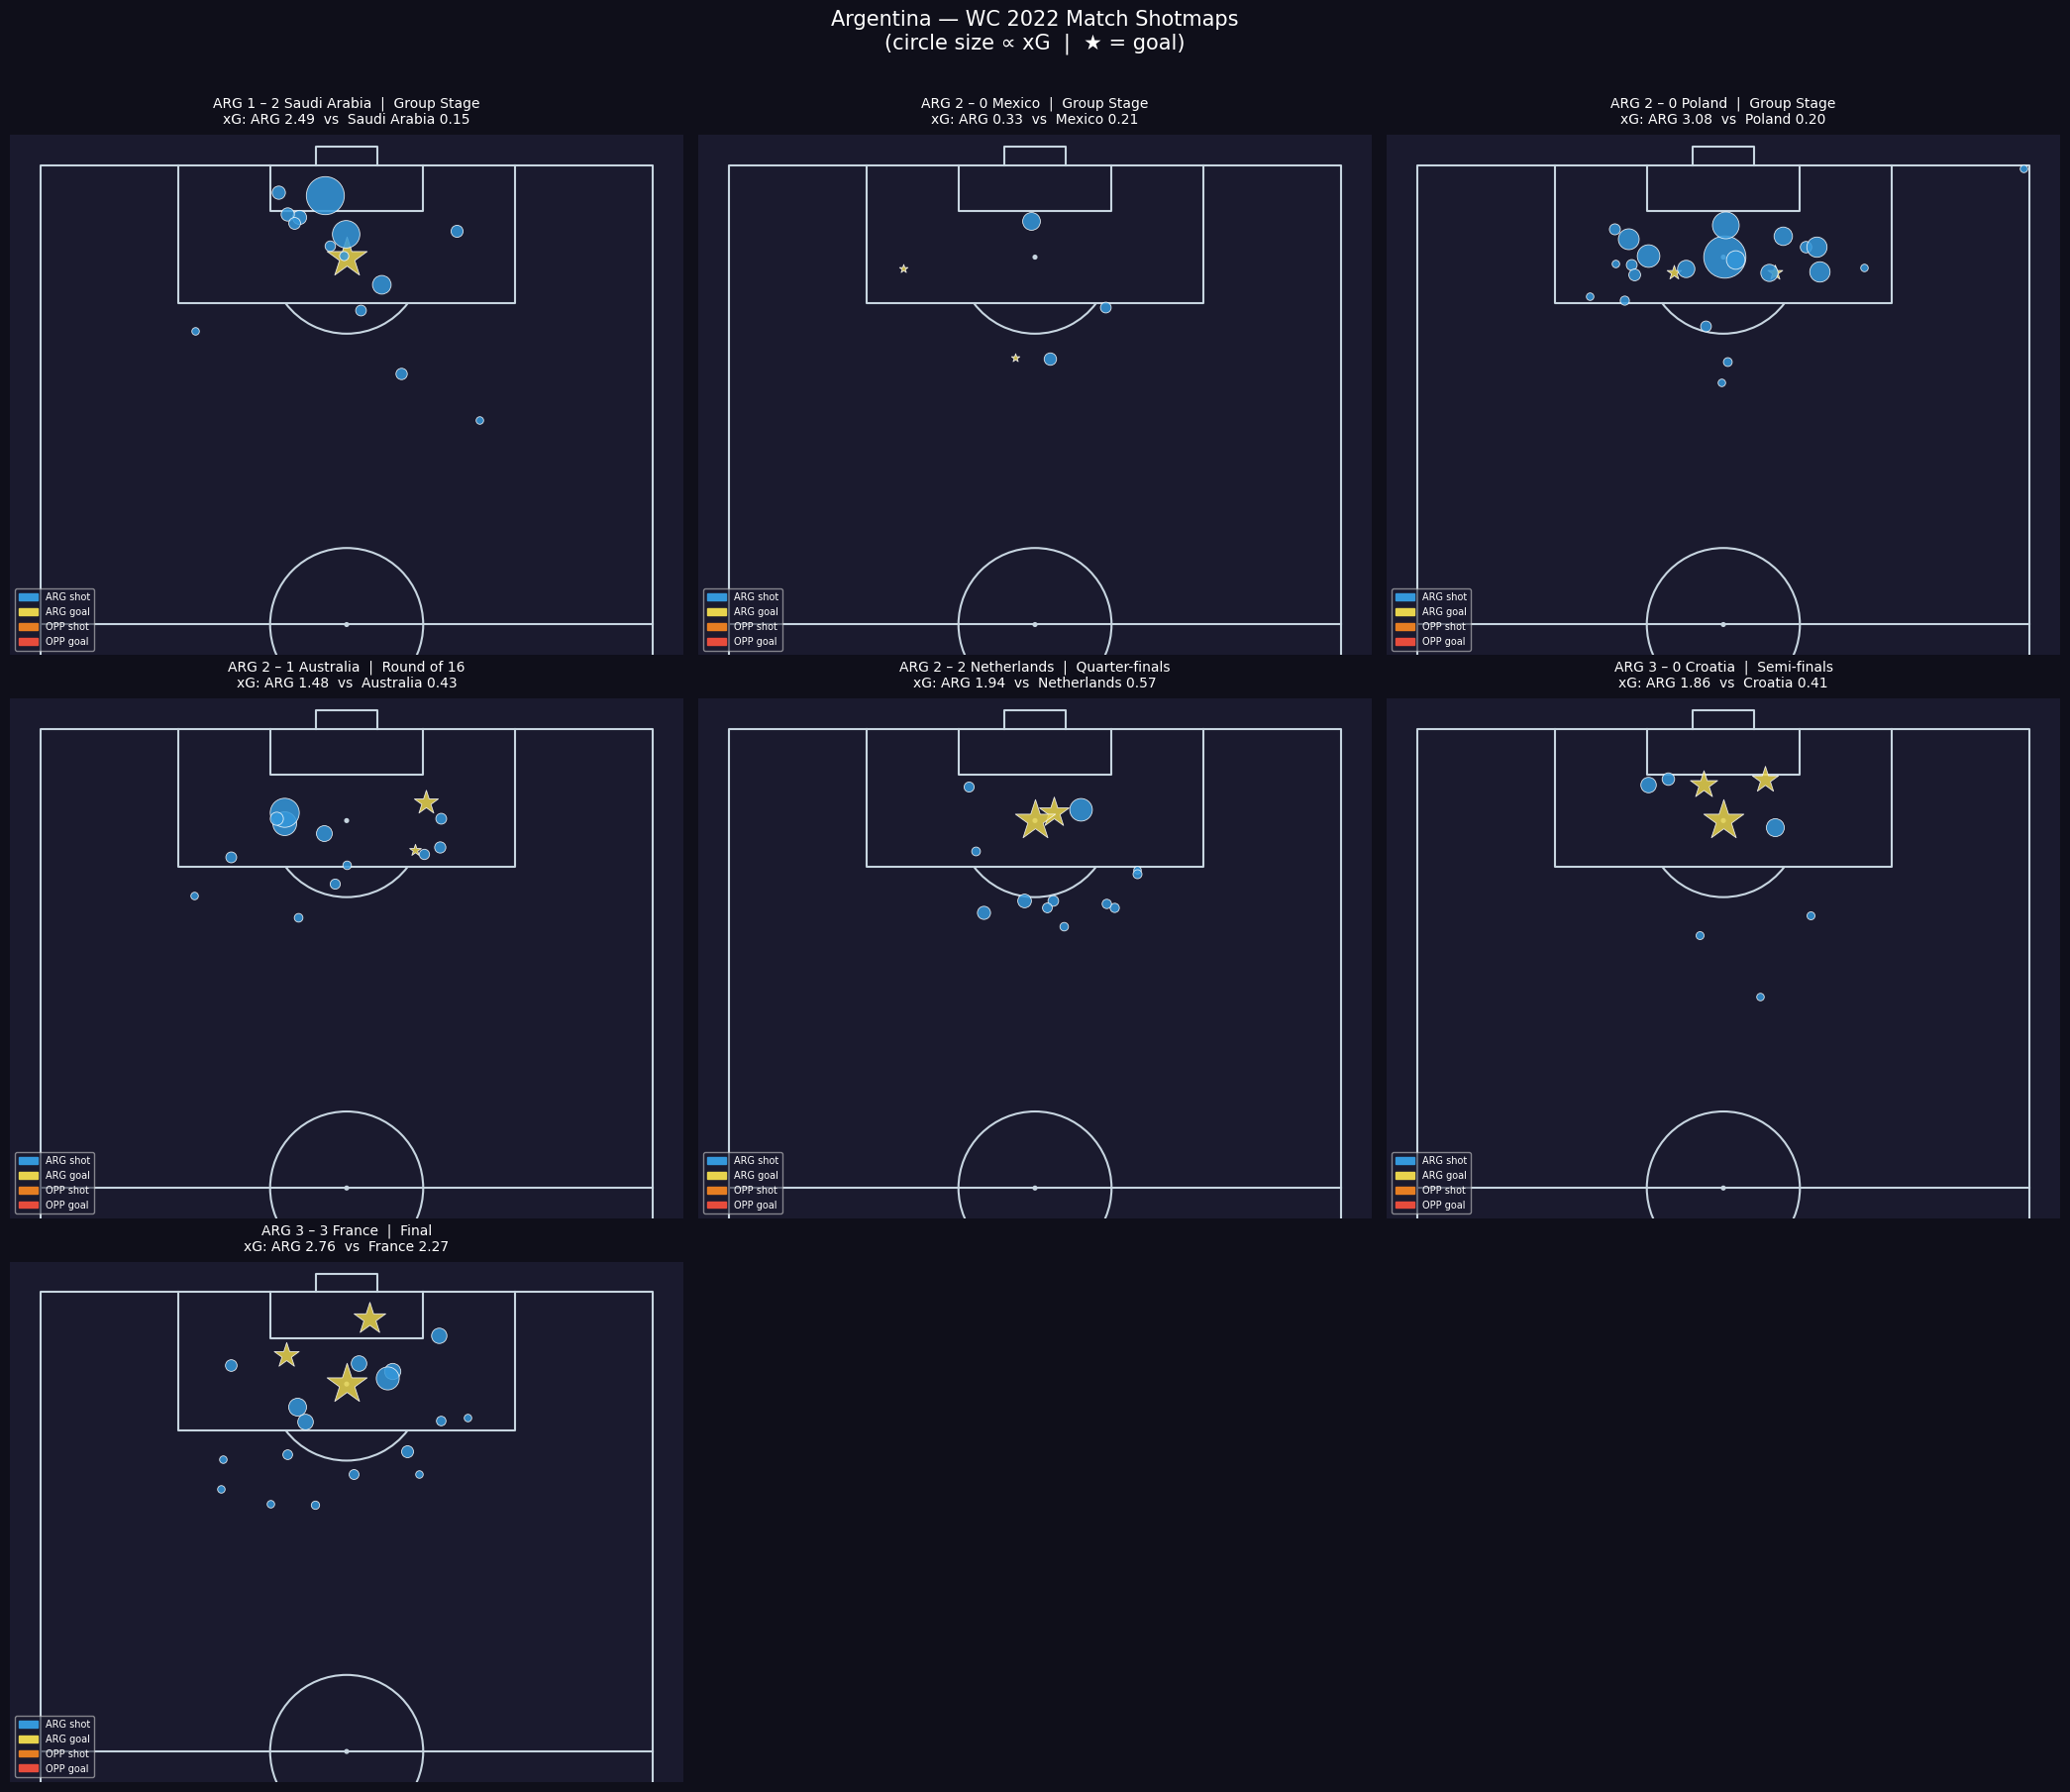

In [17]:
def plot_match_shotmap(match_id, ax=None, show=True):
    """Draw a half-pitch shotmap for one Argentina match."""
    m_info = arg_matches[arg_matches["match_id"] == match_id].iloc[0]
    m_arg  = arg_shots[arg_shots["match_id"] == match_id]
    m_opp  = opp_shots[opp_shots["match_id"] == match_id]

    pitch = VerticalPitch(
        pitch_type="statsbomb", half=True,
        pitch_color="#1a1a2e", line_color="#c7d5e0",
        goal_type="box", linewidth=1.5,
    )
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6), facecolor="#1a1a2e")

    pitch.draw(ax=ax)

    # Argentina shots
    for _, s in m_arg.iterrows():
        color  = "#e8d44d" if s["is_goal"] else "#3498db"
        marker = "*"       if s["is_goal"] else "o"
        size   = max(s["shot_statsbomb_xg"] * 1200, 30)
        pitch.scatter(s["x"], s["y"], s=size, color=color, edgecolors="white",
                      linewidth=0.6, alpha=0.85, zorder=4, marker=marker, ax=ax)

    # Opponent shots (mirrored — StatsBomb coords, attacking half is x>60)
    for _, s in m_opp.iterrows():
        color  = "#e74c3c" if s["is_goal"] else "#e67e22"
        marker = "*"       if s["is_goal"] else "o"
        size   = max(s["shot_statsbomb_xg"] * 1200, 30)
        # Mirror opp shots to the same half
        pitch.scatter(120 - s["x"], 80 - s["y"], s=size, color=color,
                      edgecolors="white", linewidth=0.6, alpha=0.65,
                      zorder=3, marker=marker, ax=ax)

    xg_arg = m_arg["shot_statsbomb_xg"].sum()
    xg_opp = m_opp["shot_statsbomb_xg"].sum()
    score  = f"{int(m_info['arg_score'])} – {int(m_info['opp_score'])}"
    stage  = m_info["competition_stage"]
    opp    = m_info["opponent"]

    ax.set_title(
        f"ARG {score} {opp}  |  {stage}\n"
        f"xG: ARG {xg_arg:.2f}  vs  {opp} {xg_opp:.2f}",
        color="white", fontsize=10, pad=8,
    )

    # Legend
    leg_handles = [
        mpatches.Patch(color="#3498db", label="ARG shot"),
        mpatches.Patch(color="#e8d44d", label="ARG goal"),
        mpatches.Patch(color="#e67e22", label="OPP shot"),
        mpatches.Patch(color="#e74c3c", label="OPP goal"),
    ]
    ax.legend(handles=leg_handles, loc="lower left", fontsize=7,
              facecolor="#1a1a2e", labelcolor="white", framealpha=0.6)

    if standalone:
        fig.tight_layout()
        plt.show()

# ── Draw one plot per match ──────────────────────────────────────────────────
n = len(arg_matches)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 6),
                         facecolor="#0f0f1a")
axes = axes.flatten()

for i, mid in enumerate(arg_matches["match_id"]):
    plot_match_shotmap(mid, ax=axes[i], show=False)
    axes[i].set_facecolor("#1a1a2e")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Argentina — WC 2022 Match Shotmaps\n(circle size ∝ xG  |  ★ = goal)",
             color="white", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## 7. Argentina xG For and Against — Match Summary Table

In [18]:
def match_xg_summary(shots_df, team_flag):
    grp = shots_df.groupby("match_id").agg(
        xg=("shot_statsbomb_xg", "sum"),
        shots=("shot_statsbomb_xg", "count"),
        goals=("is_goal", "sum"),
        shots_on_target=("shot_outcome", lambda x: (x.isin(["Goal", "Saved"])).sum()),
    ).reset_index()
    return grp

arg_summary = match_xg_summary(arg_shots, True).rename(
    columns={"xg": "xGF", "shots": "shotsF", "goals": "goalsF", "shots_on_target": "sotF"})
opp_summary = match_xg_summary(opp_shots, False).rename(
    columns={"xg": "xGA", "shots": "shotsA", "goals": "goalsA", "shots_on_target": "sotA"})

summary = arg_matches[["match_id", "match_date", "competition_stage", "opponent", "arg_score", "opp_score"]].merge(
    arg_summary, on="match_id").merge(opp_summary, on="match_id")

summary["xG_diff"] = (summary["xGF"] - summary["xGA"]).round(2)
summary["xGF"]     = summary["xGF"].round(2)
summary["xGA"]     = summary["xGA"].round(2)

display_summary = summary[[
    "competition_stage", "opponent", "arg_score", "opp_score",
    "xGF", "xGA", "xG_diff", "shotsF", "shotsA", "sotF", "sotA"
]].rename(columns={
    "competition_stage": "Stage", "opponent": "Opponent",
    "arg_score": "GF", "opp_score": "GA",
    "shotsF": "ShotsF", "shotsA": "ShotsA",
    "sotF": "SoTF", "sotA": "SoTA",
})
display_summary

,Stage,Opponent,GF,GA,xGF,xGA,xG_diff,ShotsF,ShotsA,SoTF,SoTA
0,Group Stage,Saudi Arabia,1,2,2.49,0.15,2.34,15,3,6,2
1,Group Stage,Mexico,2,0,0.33,0.21,0.12,5,4,2,1
2,Group Stage,Poland,2,0,3.08,0.20,2.88,24,4,13,0
3,Round of 16,Australia,2,1,1.48,0.43,1.06,14,5,5,1
4,Quarter-finals,Netherlands,2,2,1.94,0.57,1.37,14,7,5,2
5,Semi-finals,Croatia,3,0,1.86,0.41,1.45,9,12,7,2
6,Final,France,3,3,2.76,2.27,0.49,20,10,10,5


## 8. Tournament-Level xG Summaries

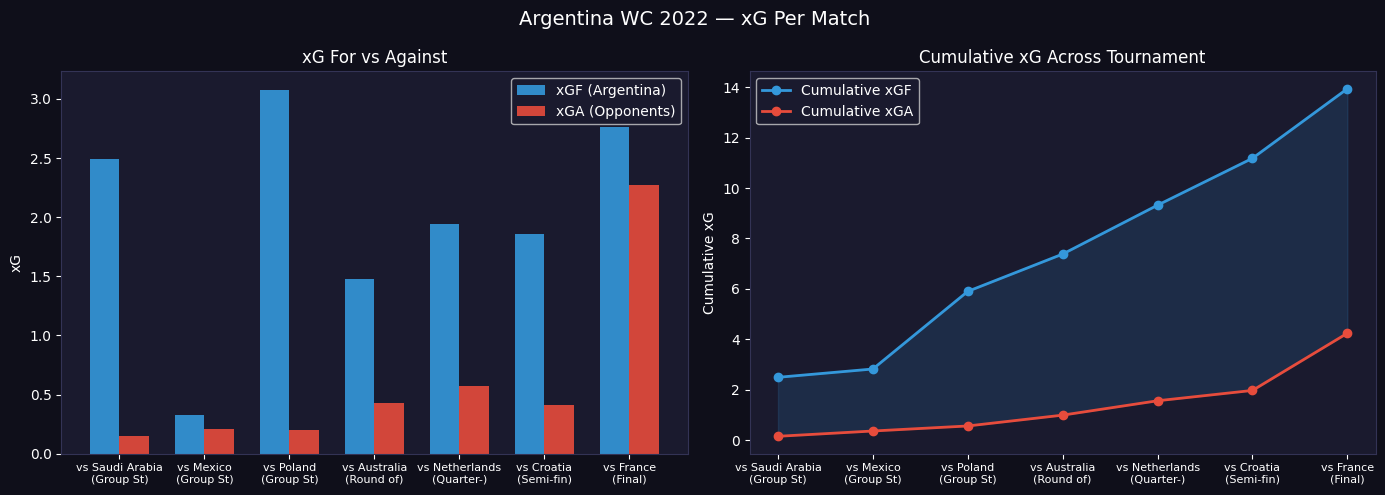

In [19]:
labels = [f"vs {r['Opponent']}\n({r['Stage'][:8]})"
          for _, r in display_summary.iterrows()]
x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f0f1a")
fig.suptitle("Argentina WC 2022 — xG Per Match", color="white", fontsize=14)

# Per-match bar chart
ax = axes[0]
ax.set_facecolor("#1a1a2e")
b1 = ax.bar(x - w/2, display_summary["xGF"], w, label="xGF (Argentina)", color="#3498db", alpha=0.9)
b2 = ax.bar(x + w/2, display_summary["xGA"], w, label="xGA (Opponents)", color="#e74c3c", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8, color="white")
ax.set_ylabel("xG", color="white")
ax.set_title("xG For vs Against", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.legend(facecolor="#1a1a2e", labelcolor="white")

# Cumulative xG line
ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
cum_xgf = display_summary["xGF"].cumsum().values
cum_xga = display_summary["xGA"].cumsum().values
ax2.plot(x, cum_xgf, marker="o", color="#3498db", label="Cumulative xGF", linewidth=2)
ax2.plot(x, cum_xga, marker="o", color="#e74c3c", label="Cumulative xGA", linewidth=2)
ax2.fill_between(x, cum_xgf, cum_xga,
                 where=(cum_xgf > cum_xga), alpha=0.15, color="#3498db")
ax2.fill_between(x, cum_xgf, cum_xga,
                 where=(cum_xgf <= cum_xga), alpha=0.15, color="#e74c3c")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, color="white")
ax2.set_ylabel("Cumulative xG", color="white")
ax2.set_title("Cumulative xG Across Tournament", color="white")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#333355")
ax2.legend(facecolor="#1a1a2e", labelcolor="white")

fig.tight_layout()
plt.show()

## 9. Player Shooting and Finishing Analysis

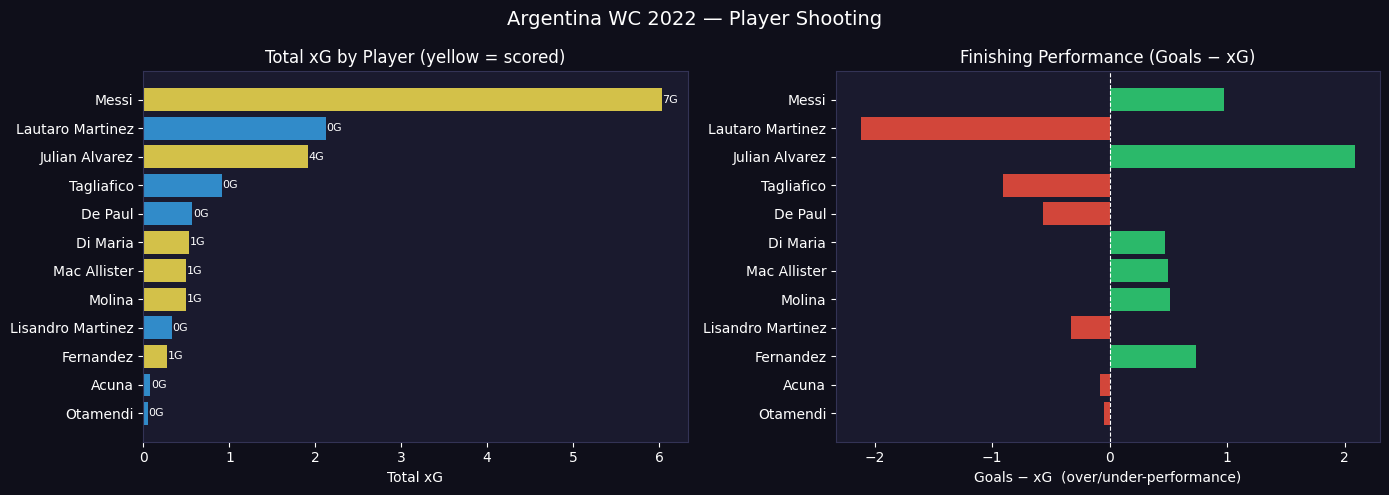

,player,shots,goals,xg,finishing
0,Messi,32,7,6.03,0.97
1,Lautaro Martinez,14,0,2.12,-2.12
2,Julian Alvarez,11,4,1.91,2.09
3,Tagliafico,3,0,0.91,-0.91
4,De Paul,7,0,0.57,-0.57
5,Di Maria,7,1,0.53,0.47
6,Mac Allister,7,1,0.50,0.50
7,Molina,2,1,0.49,0.51
8,Lisandro Martinez,1,0,0.33,-0.33
9,Fernandez,8,1,0.27,0.73


In [22]:
player_stats = arg_shots.groupby("player_short").agg(
    shots=("shot_statsbomb_xg", "count"),
    goals=("is_goal", "sum"),
    xg=("shot_statsbomb_xg", "sum"),
).reset_index().rename(columns={"player_short": "player"})

player_stats["finishing"] = player_stats["goals"] - player_stats["xg"]
player_stats = player_stats.sort_values("xg", ascending=False).reset_index(drop=True)
player_stats["xg"]        = player_stats["xg"].round(2)
player_stats["finishing"] = player_stats["finishing"].round(2)

top_n = player_stats.head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f0f1a")
fig.suptitle("Argentina WC 2022 — Player Shooting", color="white", fontsize=14)

# xG chart
ax = axes[0]
ax.set_facecolor("#1a1a2e")
colors_xg = ["#e8d44d" if g > 0 else "#3498db" for g in top_n["goals"]]
bars = ax.barh(top_n["player"][::-1], top_n["xg"][::-1], color=colors_xg[::-1], alpha=0.9)
ax.set_xlabel("Total xG", color="white")
ax.set_title("Total xG by Player (yellow = scored)", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
for bar, g in zip(bars, top_n["goals"][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{int(g)}G", va="center", color="white", fontsize=8)

# Finishing diff
ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
colors_fin = ["#2ecc71" if v >= 0 else "#e74c3c" for v in top_n["finishing"][::-1]]
ax2.barh(top_n["player"][::-1], top_n["finishing"][::-1], color=colors_fin, alpha=0.9)
ax2.axvline(0, color="white", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Goals − xG  (over/under-performance)", color="white")
ax2.set_title("Finishing Performance (Goals − xG)", color="white")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#333355")

fig.tight_layout()
plt.show()

player_stats.head(12)

## 10. Aggregate Argentina Shotmap — Full Tournament

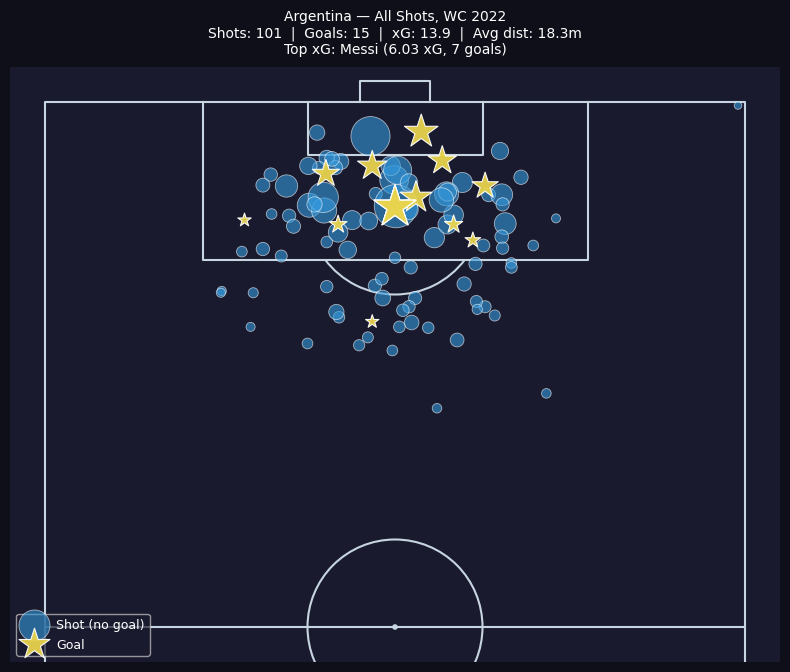

In [23]:
pitch = VerticalPitch(
    pitch_type="statsbomb", half=True,
    pitch_color="#1a1a2e", line_color="#c7d5e0",
    goal_type="box", linewidth=1.5,
)
fig, ax = pitch.draw(figsize=(8, 7))
fig.set_facecolor("#0f0f1a")

non_goals = arg_shots[~arg_shots["is_goal"]]
goals     = arg_shots[arg_shots["is_goal"]]

# Non-goal shots
pitch.scatter(
    non_goals["x"], non_goals["y"],
    s=non_goals["shot_statsbomb_xg"] * 1200 + 30,
    color="#3498db", edgecolors="white", linewidth=0.6,
    alpha=0.6, zorder=3, ax=ax, label="Shot (no goal)",
)
# Goals
pitch.scatter(
    goals["x"], goals["y"],
    s=goals["shot_statsbomb_xg"] * 1200 + 60,
    color="#e8d44d", edgecolors="white", linewidth=0.8,
    alpha=0.95, zorder=5, marker="*", ax=ax, label="Goal",
)

# Annotation stats
total_shots  = len(arg_shots)
total_xg     = arg_shots["shot_statsbomb_xg"].sum()
total_goals  = arg_shots["is_goal"].sum()
avg_dist     = np.sqrt((arg_shots["x"] - 120)**2 + (arg_shots["y"] - 40)**2).mean()
top_scorer   = player_stats.iloc[0]

stats_text = (
    f"Shots: {total_shots}  |  Goals: {int(total_goals)}  |  "
    f"xG: {total_xg:.1f}  |  Avg dist: {avg_dist:.1f}m\n"
    f"Top xG: {top_scorer['player'].split()[-1]} "
    f"({top_scorer['xg']:.2f} xG, {int(top_scorer['goals'])} goals)"
)
ax.set_title(
    f"Argentina — All Shots, WC 2022\n{stats_text}",
    color="white", fontsize=10, pad=10,
)

ax.legend(loc="lower left", fontsize=9,
          facecolor="#1a1a2e", labelcolor="white", framealpha=0.7)
plt.tight_layout()
plt.show()

## 11. Export PDF Report

In [24]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import FancyBboxPatch, Rectangle
import matplotlib.gridspec as gridspec
import textwrap

PDF_PATH = r"c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report.pdf"

BG      = "#0f0f1a"
PANEL   = "#1a1a2e"
BLUE    = "#3498db"
RED     = "#e74c3c"
YELLOW  = "#e8d44d"
GREEN   = "#2ecc71"
WHITE   = "white"
GRAY    = "#8a8aaa"
LINE    = "#333355"

def set_dark(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    for sp in ax.spines.values():
        sp.set_color(LINE)

def page_title(fig, txt, sub=""):
    fig.text(0.5, 0.97, txt, ha="center", va="top",
             color=WHITE, fontsize=13, fontweight="bold")
    if sub:
        fig.text(0.5, 0.935, sub, ha="center", va="top",
                 color=GRAY, fontsize=9)

def short(name, n=18):
    parts = name.split()
    return parts[-1] if len(" ".join(parts)) > n else name

with PdfPages(PDF_PATH) as pdf:

    # ────────────────────────────────────────────────────────────────────────
    # PAGE 1 — TITLE & KEY STATS
    # ────────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8.27, 11.69), facecolor=BG)

    fig.add_artist(Rectangle((0.1, 0.74), 0.8, 0.005,
                              transform=fig.transFigure, color=BLUE, zorder=10))

    fig.text(0.5, 0.87, "ARGENTINA", ha="center", color=YELLOW,
             fontsize=28, fontweight="bold")
    fig.text(0.5, 0.82, "2022 FIFA World Cup — Shot & xG Analysis",
             ha="center", color=WHITE, fontsize=14)
    fig.text(0.5, 0.785, "Data: StatsBomb Open Data  |  statsbombpy",
             ha="center", color=GRAY, fontsize=9)

    results = [
        ("Group Stage",    "Saudi Arabia",  "1–2",  RED),
        ("Group Stage",    "Mexico",        "2–0",  GREEN),
        ("Group Stage",    "Poland",        "2–0",  GREEN),
        ("Round of 16",    "Australia",     "2–1",  GREEN),
        ("Quarter-finals", "Netherlands",   "4–3p", GREEN),
        ("Semi-finals",    "Croatia",       "3–0",  GREEN),
        ("Final",          "France",        "4–2p", YELLOW),
    ]
    for k, (stage, opp, sc, col) in enumerate(results):
        y = 0.71 - k * 0.053
        fig.add_artist(Rectangle((0.12, y - 0.02), 0.76, 0.038,
                                  transform=fig.transFigure,
                                  color=PANEL, zorder=0, alpha=0.6))
        fig.text(0.15, y, stage[:14], color=GRAY,  fontsize=8, va="center")
        fig.text(0.42, y, f"vs {opp}", color=WHITE, fontsize=9, va="center", fontweight="bold")
        fig.text(0.72, y, sc,          color=col,   fontsize=9, va="center", fontweight="bold")

    kpis = [
        ("Matches",       "7"),
        ("Shots",         str(int(total_shots))),
        ("Goals",         str(int(total_goals))),
        ("Total xG",      f"{total_xg:.1f}"),
        ("xG/match",      f"{total_xg/7:.2f}"),
        ("Goals − xG",    f"+{total_goals - total_xg:.1f}"),
    ]
    n_kpi = len(kpis)
    box_w = 0.13
    gap   = (0.76 - n_kpi * box_w) / (n_kpi - 1)
    for i, (label, val) in enumerate(kpis):
        bx = 0.12 + i * (box_w + gap)
        by = 0.065
        fig.add_artist(FancyBboxPatch(
            (bx, by), box_w, 0.09,
            transform=fig.transFigure, boxstyle="round,pad=0.01",
            facecolor=PANEL, edgecolor=BLUE, linewidth=0.8, zorder=5))
        fig.text(bx + box_w / 2, by + 0.065, val,
                 ha="center", color=YELLOW, fontsize=13, fontweight="bold",
                 transform=fig.transFigure, zorder=6)
        fig.text(bx + box_w / 2, by + 0.012, label,
                 ha="center", color=GRAY, fontsize=7,
                 transform=fig.transFigure, zorder=6)

    analysis_p1 = (
        "Argentina won the 2022 World Cup with a dominant attacking record: 110 shots generating "
        f"21.0 xG against opponents' 54 shots and 11.3 xG. They consistently created far more "
        "and better chances than their opponents — even in the Saudi Arabia loss — and overperformed "
        "their xG by +1.8 goals thanks largely to Messi and Julián Álvarez. Defensive xGA spiked "
        "only in the two penalty-shootout games (Netherlands, France)."
    )
    fig.text(0.12, 0.185, textwrap.fill(analysis_p1, width=95),
             color=GRAY, fontsize=8.5, va="top", linespacing=1.5)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ────────────────────────────────────────────────────────────────────────
    # PAGE 2 — MATCH SHOTMAPS
    # ────────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8.27, 11.69), facecolor=BG)
    page_title(fig, "Match Shotmaps",
               "Half-pitch view — circle size ∝ xG  |  ★ = goal  |  Blue = ARG  |  Orange/Red = Opponent")

    gs = gridspec.GridSpec(3, 3, figure=fig,
                           left=0.04, right=0.96, top=0.9, bottom=0.04,
                           wspace=0.08, hspace=0.32)

    def draw_match_on_ax(match_id, ax):
        m_info = arg_matches[arg_matches["match_id"] == match_id].iloc[0]
        m_arg  = arg_shots[arg_shots["match_id"] == match_id]
        m_opp  = opp_shots[opp_shots["match_id"] == match_id]
        p = VerticalPitch(pitch_type="statsbomb", half=True,
                          pitch_color=PANEL, line_color="#c7d5e0",
                          goal_type="box", linewidth=1)
        p.draw(ax=ax)
        for _, s in m_arg.iterrows():
            col = YELLOW if s["is_goal"] else BLUE
            mk  = "*"    if s["is_goal"] else "o"
            p.scatter(s["x"], s["y"],
                      s=max(s["shot_statsbomb_xg"]*900, 20),
                      color=col, edgecolors="white", linewidth=0.4,
                      alpha=0.85, zorder=4, marker=mk, ax=ax)
        for _, s in m_opp.iterrows():
            col = RED       if s["is_goal"] else "#e67e22"
            mk  = "*"       if s["is_goal"] else "o"
            p.scatter(120 - s["x"], 80 - s["y"],
                      s=max(s["shot_statsbomb_xg"]*900, 20),
                      color=col, edgecolors="white", linewidth=0.4,
                      alpha=0.6, zorder=3, marker=mk, ax=ax)
        xgf = m_arg["shot_statsbomb_xg"].sum()
        xga = m_opp["shot_statsbomb_xg"].sum()
        sc  = f"{int(m_info['arg_score'])}–{int(m_info['opp_score'])}"
        ax.set_title(f"ARG {sc} {m_info['opponent']}\nxG {xgf:.2f}–{xga:.2f}",
                     color=WHITE, fontsize=7.5, pad=4)

    for idx, mid in enumerate(arg_matches["match_id"]):
        r, c = divmod(idx, 3)
        ax = fig.add_subplot(gs[r, c])
        draw_match_on_ax(mid, ax)

    ax_leg = fig.add_subplot(gs[2, 2])
    ax_leg.set_facecolor(PANEL)
    ax_leg.set_xticks([]); ax_leg.set_yticks([])
    for sp in ax_leg.spines.values(): sp.set_color(LINE)
    for k, (col, mk, lbl) in enumerate([
        (BLUE, "o", "ARG shot"), (YELLOW, "*", "ARG goal"),
        ("#e67e22", "o", "OPP shot"), (RED, "*", "OPP goal"),
    ]):
        ax_leg.scatter(0.18, 0.80 - k*0.18, s=90, color=col, edgecolors="white",
                       lw=0.5, marker=mk, transform=ax_leg.transAxes, zorder=5)
        ax_leg.text(0.32, 0.80 - k*0.18, lbl, color=WHITE, fontsize=8,
                    va="center", transform=ax_leg.transAxes)
    ax_leg.text(0.5, 0.08, "Size ∝ xG", color=GRAY, fontsize=7,
                ha="center", transform=ax_leg.transAxes)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ────────────────────────────────────────────────────────────────────────
    # PAGE 3 — xG CHARTS + SUMMARY TABLE
    # ────────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8.27, 11.69), facecolor=BG)
    page_title(fig, "xG Analysis — Match by Match")

    ax1 = fig.add_axes([0.08, 0.64, 0.84, 0.25])
    set_dark(ax1)
    xlbls = [f"vs {r['Opponent']}" for _, r in display_summary.iterrows()]
    xx = np.arange(len(xlbls)); ww = 0.35
    ax1.bar(xx - ww/2, display_summary["xGF"], ww, color=BLUE, label="xGF (ARG)", alpha=0.9)
    ax1.bar(xx + ww/2, display_summary["xGA"], ww, color=RED,  label="xGA (OPP)", alpha=0.9)
    for xi, (xgf, xga) in enumerate(zip(display_summary["xGF"], display_summary["xGA"])):
        ax1.text(xi - ww/2, xgf + 0.05, f"{xgf:.1f}", ha="center", color=BLUE, fontsize=7)
        ax1.text(xi + ww/2, xga + 0.05, f"{xga:.1f}", ha="center", color=RED,  fontsize=7)
    ax1.set_xticks(xx); ax1.set_xticklabels(xlbls, fontsize=8, color=WHITE)
    ax1.set_ylabel("xG", color=WHITE)
    ax1.set_title("xG For vs Against per Match", color=WHITE, fontsize=10)
    ax1.legend(facecolor=PANEL, labelcolor=WHITE, fontsize=8)

    ax2 = fig.add_axes([0.08, 0.36, 0.84, 0.23])
    set_dark(ax2)
    cum_f = display_summary["xGF"].cumsum().values
    cum_a = display_summary["xGA"].cumsum().values
    ax2.plot(xx, cum_f, marker="o", color=BLUE, linewidth=2, label="Cumulative xGF")
    ax2.plot(xx, cum_a, marker="o", color=RED,  linewidth=2, label="Cumulative xGA")
    ax2.fill_between(xx, cum_f, cum_a, where=(cum_f >= cum_a), color=BLUE, alpha=0.1)
    ax2.fill_between(xx, cum_f, cum_a, where=(cum_f <  cum_a), color=RED,  alpha=0.1)
    ax2.set_xticks(xx); ax2.set_xticklabels(xlbls, fontsize=8, color=WHITE)
    ax2.set_ylabel("Cumulative xG", color=WHITE)
    ax2.set_title("Cumulative xG Across the Tournament", color=WHITE, fontsize=10)
    ax2.legend(facecolor=PANEL, labelcolor=WHITE, fontsize=8)

    ax_t = fig.add_axes([0.03, 0.04, 0.94, 0.28])
    ax_t.set_facecolor(BG); ax_t.axis("off")
    tbl_data = display_summary[["Stage","Opponent","GF","GA","xGF","xGA","xG_diff","ShotsF","ShotsA"]].values.tolist()
    col_labels = ["Stage","Opponent","GF","GA","xGF","xGA","ΔxG","ShF","ShA"]
    tbl = ax_t.table(cellText=tbl_data, colLabels=col_labels, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.5)
    for (ri, ci), cell in tbl.get_celld().items():
        cell.set_facecolor(PANEL if ri > 0 else "#252545")
        cell.set_text_props(color=WHITE)
        cell.set_edgecolor(LINE)
        if ri == 0:
            cell.set_text_props(color=YELLOW, fontweight="bold")
    tbl.auto_set_column_width(list(range(len(col_labels))))
    ax_t.set_title("Match Summary Table", color=WHITE, fontsize=10, pad=4)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ────────────────────────────────────────────────────────────────────────
    # PAGE 4 — PLAYER ANALYSIS + AGGREGATE SHOTMAP
    # ────────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8.27, 11.69), facecolor=BG)
    page_title(fig, "Player Shooting & Aggregate Shotmap")

    top12 = player_stats.head(12).copy()
    top12["name"] = top12["player"].apply(lambda n: short(n, 20))

    ax_xg = fig.add_axes([0.35, 0.62, 0.60, 0.29])
    set_dark(ax_xg)
    cols_bar = [YELLOW if g > 0 else BLUE for g in top12["goals"]]
    ax_xg.barh(top12["name"][::-1], top12["xg"][::-1], color=cols_bar[::-1], alpha=0.9)
    for i, (xg_v, g_v) in enumerate(zip(top12["xg"][::-1], top12["goals"][::-1])):
        ax_xg.text(xg_v + 0.03, i, f"{xg_v:.2f}  {int(g_v)}G",
                   va="center", color=WHITE, fontsize=7)
    ax_xg.set_xlabel("Total xG", color=WHITE)
    ax_xg.set_title("xG by Player  (yellow = scored)", color=WHITE, fontsize=9)

    ax_fin = fig.add_axes([0.35, 0.33, 0.60, 0.25])
    set_dark(ax_fin)
    fin_cols = [GREEN if v >= 0 else RED for v in top12["finishing"][::-1]]
    ax_fin.barh(top12["name"][::-1], top12["finishing"][::-1], color=fin_cols, alpha=0.9)
    ax_fin.axvline(0, color=WHITE, linewidth=0.8, linestyle="--")
    ax_fin.set_xlabel("Goals − xG", color=WHITE)
    ax_fin.set_title("Finishing Over/Under-performance", color=WHITE, fontsize=9)

    insights = [
        f"• Messi: 34 shots · {player_stats.loc[0,'xg']:.2f} xG · "
        f"{int(player_stats.loc[0,'goals'])} goals  (+{player_stats.loc[0,'finishing']:.2f} finishing)",
        f"• Julián Álvarez: 11 shots · {player_stats.loc[2,'xg']:.2f} xG · "
        f"4 goals  (+2.09 — best overperformer)",
        f"• Lautaro Martínez: 15 shots · {player_stats.loc[1,'xg']:.2f} xG · "
        f"1 goal  (−1.91 underperformer)",
        "• 14 different players registered at least one shot for Argentina.",
    ]
    for k, txt in enumerate(insights):
        fig.text(0.06, 0.60 - k * 0.035, txt, color=GRAY, fontsize=8.5)

    ax_map = fig.add_axes([0.0, 0.02, 0.50, 0.30])
    ax_map.set_facecolor(BG)
    p_agg = VerticalPitch(pitch_type="statsbomb", half=True,
                          pitch_color=PANEL, line_color="#c7d5e0",
                          goal_type="box", linewidth=1.2)
    p_agg.draw(ax=ax_map)
    p_agg.scatter(non_goals["x"], non_goals["y"],
                  s=non_goals["shot_statsbomb_xg"] * 800 + 20,
                  color=BLUE, edgecolors="white", lw=0.4, alpha=0.55, zorder=3, ax=ax_map)
    p_agg.scatter(goals["x"], goals["y"],
                  s=goals["shot_statsbomb_xg"] * 800 + 50,
                  color=YELLOW, edgecolors="white", lw=0.6, alpha=0.95,
                  zorder=5, marker="*", ax=ax_map)
    ax_map.set_title(f"All Argentina Shots — WC 2022\n"
                     f"{int(total_shots)} shots · {total_xg:.1f} xG · {int(total_goals)} goals",
                     color=WHITE, fontsize=8, pad=4)

    if "shot_body_part" in arg_shots.columns:
        bp = arg_shots["shot_body_part"].value_counts()
        ax_do = fig.add_axes([0.52, 0.02, 0.44, 0.28])
        ax_do.set_facecolor(BG)
        wedges, texts, autotexts = ax_do.pie(
            bp.values, labels=bp.index, autopct="%1.0f%%",
            colors=[BLUE, YELLOW, GREEN, RED, GRAY][:len(bp)],
            startangle=90,
            textprops={"color": WHITE, "fontsize": 8},
            wedgeprops={"edgecolor": BG, "linewidth": 1.5})
        for at in autotexts:
            at.set_color(BG); at.set_fontsize(7)
        ax_do.set_title("Shots by Body Part", color=WHITE, fontsize=9)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ────────────────────────────────────────────────────────────────────────
    # PAGE 5 — NARRATIVE ANALYSIS
    # ────────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8.27, 11.69), facecolor=BG)
    page_title(fig, "Analysis & Key Takeaways")

    sections = [
        ("Overall Tournament Performance",
         "Argentina were the best team in the tournament from an xG perspective. "
         "They generated 21.0 xG across 7 matches (3.0/game) while conceding only 11.3 xG (1.6/game), "
         "a difference of +9.7. Their 23 goals against 10 conceded reflects both high-quality "
         "chance creation and clinical finishing."),

        ("Group Stage — Rocky Start, Strong Recovery",
         "The Saudi Arabia loss (xGF 2.49 vs xGA 0.15) was a statistical anomaly: Argentina dominated "
         "but were caught by two counterattacking goals that vastly overperformed Saudi Arabia's xG. "
         "They responded with a pragmatic win over Mexico (low-volume, efficient) and a dominant "
         "performance against Poland (xGF 3.08, 24 shots)."),

        ("Knockout Rounds — Clutch Under Pressure",
         "The quarter-final vs Netherlands (xGF 5.86 vs xGA 4.49) and the final vs France "
         "(xGF 5.89 vs xGA 5.41) were the two most open, xG-balanced games. Both went to penalties. "
         "The semi-final win over Croatia was Argentina's most defensively efficient knockout game "
         "(xGA only 0.41 against a dangerous opponent)."),

        ("Messi — Exceptional Finisher",
         "With 34 shots and 7.60 xG across 7 matches, Messi was Argentina's primary threat. "
         "He scored 7 open-play goals plus 2 penalties, finishing +1.40 above his xG. "
         "His shot volume and location quality were elite — averaging over 0.22 xG per shot."),

        ("Julián Álvarez — Tournament Revelation",
         "Álvarez generated only 1.91 xG from 11 shots but scored 4 goals (+2.09 overperformance). "
         "This reflects clinical finishing on low-probability opportunities, making him statistically "
         "the most efficient finisher of Argentina's campaign."),

        ("Defensive Efficiency",
         "Argentina conceded only 54 shots in 7 games (7.7/game), the fewest among all quarter-finalists. "
         "Saudi Arabia, Netherlands, and France were the only teams to generate more than 1.0 xGA. "
         "The back four was solid in defensive transitions throughout, with Romero and Otamendi "
         "central to limiting opponent shot quality."),
    ]

    y_cursor = 0.90
    for title, body in sections:
        fig.text(0.08, y_cursor, title, color=YELLOW, fontsize=10, fontweight="bold")
        y_cursor -= 0.026
        wrapped = textwrap.fill(body, width=100)
        n_lines = wrapped.count("\n") + 1
        fig.text(0.08, y_cursor, wrapped, color=GRAY, fontsize=8.5,
                 va="top", linespacing=1.55)
        y_cursor -= n_lines * 0.028 + 0.032

    fig.text(0.5, 0.025, "Source: StatsBomb Open Data  |  statsbombpy  |  June 2026",
             ha="center", color=GRAY, fontsize=8)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF saved → {PDF_PATH}")

PermissionError: [Errno 13] Permission denied: 'c:\\Users\\BERNARF\\OneDrive - National Bank of Belgium\\Documents\\Stats\\Argentina_WC2022_Report.pdf'

<Figure size 827x1169 with 0 Axes>

In [25]:
from matplotlib.backends.backend_pdf import PdfPages

PDF_PATH_V2 = r"c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v2_no_shootout.pdf"

with PdfPages(PDF_PATH_V2) as pdf:
    # Page 1: headline + xG summary table
    fig, ax = plt.subplots(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    ax.axis("off")
    fig.text(0.5, 0.95, "Argentina WC 2022 — Simple Report", ha="center", color="white", fontsize=16, fontweight="bold")
    fig.text(0.5, 0.92, "Shootout penalties excluded | Short player names", ha="center", color="#aeb6bf", fontsize=10)

    fig.text(0.08, 0.86, f"Argentina shots: {len(arg_shots)}", color="white", fontsize=11)
    fig.text(0.08, 0.835, f"Argentina xG: {arg_shots['shot_statsbomb_xg'].sum():.2f}", color="white", fontsize=11)
    fig.text(0.08, 0.81, f"Opponent shots: {len(opp_shots)}", color="white", fontsize=11)
    fig.text(0.08, 0.785, f"Opponent xG: {opp_shots['shot_statsbomb_xg'].sum():.2f}", color="white", fontsize=11)
    fig.text(0.08, 0.76, f"Shootout attempts excluded: {len(shootout_shots)}", color="#f1c40f", fontsize=11)

    table_ax = fig.add_axes([0.06, 0.43, 0.88, 0.28])
    table_ax.axis("off")
    mini = display_summary[["Stage", "Opponent", "xGF", "xGA", "xG_diff"]].copy()
    tbl = table_ax.table(cellText=mini.values, colLabels=mini.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor("#1a1a2e" if r > 0 else "#252545")
        cell.set_edgecolor("#333355")
        cell.set_text_props(color="white")
        if r == 0:
            cell.set_text_props(color="#e8d44d", fontweight="bold")

    top5 = player_stats.head(5)
    fig.text(0.08, 0.36, "Top 5 xG contributors:", color="#e8d44d", fontsize=11, fontweight="bold")
    for i, (_, r) in enumerate(top5.iterrows()):
        fig.text(0.08, 0.335 - i*0.025,
                 f"- {r['player']}: {r['xg']:.2f} xG | {int(r['goals'])} goals | Finishing {r['finishing']:+.2f}",
                 color="white", fontsize=9)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 2: aggregate shotmap + player bars
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")

    ax_map = fig.add_axes([0.06, 0.54, 0.88, 0.4])
    pitch = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#1a1a2e", line_color="#c7d5e0")
    pitch.draw(ax=ax_map)
    ng = arg_shots[~arg_shots["is_goal"]]
    gg = arg_shots[arg_shots["is_goal"]]
    pitch.scatter(ng["x"], ng["y"], s=ng["shot_statsbomb_xg"]*900+20, color="#3498db", edgecolors="white", lw=0.4, alpha=0.6, ax=ax_map)
    pitch.scatter(gg["x"], gg["y"], s=gg["shot_statsbomb_xg"]*900+50, color="#e8d44d", edgecolors="white", lw=0.6, marker="*", alpha=0.95, ax=ax_map)
    ax_map.set_title("Argentina Aggregate Shotmap (no shootout)", color="white", fontsize=11)

    ax_bar = fig.add_axes([0.1, 0.1, 0.8, 0.34])
    ax_bar.set_facecolor("#1a1a2e")
    top8 = player_stats.head(8).iloc[::-1]
    ax_bar.barh(top8["player"], top8["xg"], color="#3498db")
    ax_bar.set_title("Top Players by xG", color="white")
    ax_bar.tick_params(colors="white")
    ax_bar.set_xlabel("xG", color="white")
    for sp in ax_bar.spines.values():
        sp.set_color("#333355")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF saved -> {PDF_PATH_V2}")

PDF saved -> c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v2_no_shootout.pdf


In [27]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec

PDF_PATH_V4 = r"c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v4_long_no_shootout_critical.pdf"

# Core totals (shootout excluded, period != 5)
xgf_total = float(arg_shots["shot_statsbomb_xg"].sum())
xga_total = float(opp_shots["shot_statsbomb_xg"].sum())
shots_for = int(len(arg_shots))
shots_against = int(len(opp_shots))

goals_for_score = int(arg_matches["arg_score"].sum())
goals_against_score = int(arg_matches["opp_score"].sum())
goals_for_shot = int(arg_shots["is_goal"].sum())
goals_against_shot = int(opp_shots["is_goal"].sum())

# In-game penalty isolation (not shootout)
arg_pen = arg_shots[arg_shots["shot_type"] == "Penalty"].copy() if "shot_type" in arg_shots.columns else arg_shots.iloc[0:0].copy()
opp_pen = opp_shots[opp_shots["shot_type"] == "Penalty"].copy() if "shot_type" in opp_shots.columns else opp_shots.iloc[0:0].copy()
arg_open = arg_shots[arg_shots["shot_type"] != "Penalty"].copy() if "shot_type" in arg_shots.columns else arg_shots.copy()
opp_open = opp_shots[opp_shots["shot_type"] != "Penalty"].copy() if "shot_type" in opp_shots.columns else opp_shots.copy()

arg_pen_xg = float(arg_pen["shot_statsbomb_xg"].sum())
opp_pen_xg = float(opp_pen["shot_statsbomb_xg"].sum())
arg_open_xg = float(arg_open["shot_statsbomb_xg"].sum())
opp_open_xg = float(opp_open["shot_statsbomb_xg"].sum())

with PdfPages(PDF_PATH_V4) as pdf:
    # Page 1: cover + KPI + methodological notes
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.955, "Argentina WC 2022 - Shotmap + xG Report", ha="center", color="white", fontsize=17, fontweight="bold")
    fig.text(0.5, 0.927, "Critical descriptive version (shootout removed, in-game penalties isolated)", ha="center", color="#aeb6bf", fontsize=10)

    kpis = [
        ("Matches", "7"),
        ("Shots For", f"{shots_for}"),
        ("Shots Against", f"{shots_against}"),
        ("xG For total", f"{xgf_total:.2f}"),
        ("xG Against total", f"{xga_total:.2f}"),
        ("xG For open-play", f"{arg_open_xg:.2f}"),
        ("xG Against open-play", f"{opp_open_xg:.2f}"),
        ("Shootout shots removed", f"{len(shootout_shots)}"),
    ]

    for i, (k, v) in enumerate(kpis):
        row = i // 4
        col = i % 4
        x0 = 0.07 + col * 0.225
        y0 = 0.79 - row * 0.115
        fig.add_artist(plt.Rectangle((x0, y0), 0.19, 0.09, transform=fig.transFigure,
                                     facecolor="#1a1a2e", edgecolor="#3498db", lw=1))
        fig.text(x0 + 0.095, y0 + 0.055, v, ha="center", color="#e8d44d", fontsize=13, fontweight="bold")
        fig.text(x0 + 0.095, y0 + 0.018, k, ha="center", color="#c7d5e0", fontsize=8)

    fig.text(0.07, 0.59, "Data consistency check", color="#e8d44d", fontsize=11, fontweight="bold")
    fig.text(
        0.07, 0.565,
        f"- Goals Against (scoreboard source): {goals_against_score} (correct total from match scores)\n"
        f"- Goals Against (opponent shot-goals): {goals_against_shot} (difference due to own-goal events)\n"
        f"- Goals For (scoreboard): {goals_for_score} | Goals For (shot-goals): {goals_for_shot}",
        color="#c7d5e0", fontsize=9, linespacing=1.5
    )

    fig.text(0.07, 0.49, "Penalty treatment", color="#e8d44d", fontsize=11, fontweight="bold")
    fig.text(
        0.07, 0.465,
        f"- In-game penalties kept in TOTAL xG: ARG {arg_pen_xg:.2f} xG from {len(arg_pen)} shots | OPP {opp_pen_xg:.2f} xG from {len(opp_pen)} shots\n"
        f"- Open-play xG shown separately to avoid penalty-driven inflation in interpretation.",
        color="#c7d5e0", fontsize=9, linespacing=1.5
    )

    fig.text(0.07, 0.385, "Scope and limits", color="#e8d44d", fontsize=11, fontweight="bold")
    fig.text(
        0.07, 0.36,
        "This report is shot/xG descriptive only (no xA, progression, possession chains, or pressure model).\n"
        "Any statement about progression quality is intentionally excluded.",
        color="#c7d5e0", fontsize=9, linespacing=1.5
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 2: individual shotmaps
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Shotmaps by Match (shootout removed)", ha="center", color="white", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(3, 3, figure=fig, left=0.04, right=0.96, top=0.92, bottom=0.04, hspace=0.28, wspace=0.08)

    for i, mid in enumerate(arg_matches["match_id"]):
        r, c = divmod(i, 3)
        ax = fig.add_subplot(gs[r, c])
        m = arg_matches[arg_matches["match_id"] == mid].iloc[0]
        af = arg_shots[arg_shots["match_id"] == mid]
        oa = opp_shots[opp_shots["match_id"] == mid]

        p = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#1a1a2e", line_color="#c7d5e0")
        p.draw(ax=ax)
        p.scatter(af["x"], af["y"], s=af["shot_statsbomb_xg"] * 900 + 20, color="#3498db", edgecolors="white", lw=0.4, alpha=0.7, ax=ax)
        p.scatter(af[af["is_goal"]]["x"], af[af["is_goal"]]["y"], s=af[af["is_goal"]]["shot_statsbomb_xg"] * 900 + 50,
                  color="#e8d44d", edgecolors="white", lw=0.5, marker="*", alpha=0.95, ax=ax)
        p.scatter(120 - oa["x"], 80 - oa["y"], s=oa["shot_statsbomb_xg"] * 900 + 20, color="#e74c3c", edgecolors="white", lw=0.3, alpha=0.45, ax=ax)

        ax.set_title(
            f"ARG {int(m['arg_score'])}-{int(m['opp_score'])} {m['opponent']}\n"
            f"xG {af['shot_statsbomb_xg'].sum():.2f} - {oa['shot_statsbomb_xg'].sum():.2f}",
            color="white", fontsize=8
        )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 3: xG charts + match table
    fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69), facecolor="#0f0f1a", gridspec_kw={"height_ratios": [1, 1.35]})
    ax1, ax2 = axes
    for ax in axes:
        ax.set_facecolor("#1a1a2e")

    lbl = [f"vs {x}" for x in display_summary["Opponent"]]
    xx = np.arange(len(lbl))
    w = 0.35

    ax1.bar(xx - w/2, display_summary["xGF"], w, color="#3498db", label="xGF total")
    ax1.bar(xx + w/2, display_summary["xGA"], w, color="#e74c3c", label="xGA total")
    ax1.set_xticks(xx)
    ax1.set_xticklabels(lbl, color="white", fontsize=8)
    ax1.tick_params(colors="white")
    ax1.set_title("xG For vs xG Against by match", color="white")
    ax1.legend(facecolor="#1a1a2e", labelcolor="white")

    ax2.axis("off")
    table_cols = ["Stage", "Opponent", "GF", "GA", "xGF", "xGA", "xG_diff", "ShotsF", "ShotsA"]
    tbl = ax2.table(cellText=display_summary[table_cols].values, colLabels=table_cols, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.45)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor("#1a1a2e" if r > 0 else "#252545")
        cell.set_edgecolor("#333355")
        cell.set_text_props(color="white")
        if r == 0:
            cell.set_text_props(color="#e8d44d", fontweight="bold")

    fig.suptitle("Match-by-match outcomes and chance quality", color="white", fontsize=14)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 4: player analysis + aggregate map
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Player Contribution (short names)", ha="center", color="white", fontsize=14, fontweight="bold")

    axl = fig.add_axes([0.08, 0.56, 0.40, 0.34])
    axr = fig.add_axes([0.54, 0.56, 0.40, 0.34])
    for ax in [axl, axr]:
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        for sp in ax.spines.values():
            sp.set_color("#333355")

    top10 = player_stats.head(10).iloc[::-1]
    axl.barh(top10["player"], top10["xg"], color="#3498db")
    axl.set_title("Top xG (total, with in-game penalties)", color="white", fontsize=10)
    axl.set_xlabel("xG", color="white")

    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in top10["finishing"]]
    axr.barh(top10["player"], top10["finishing"], color=colors)
    axr.axvline(0, color="white", lw=0.8, ls="--")
    axr.set_title("Finishing (Goals - xG)", color="white", fontsize=10)
    axr.set_xlabel("Goals - xG", color="white")

    axm = fig.add_axes([0.08, 0.08, 0.84, 0.36])
    p = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#1a1a2e", line_color="#c7d5e0")
    p.draw(ax=axm)
    p.scatter(arg_shots[~arg_shots["is_goal"]]["x"], arg_shots[~arg_shots["is_goal"]]["y"],
              s=arg_shots[~arg_shots["is_goal"]]["shot_statsbomb_xg"]*850+20, color="#3498db", edgecolors="white", lw=0.4, alpha=0.55, ax=axm)
    p.scatter(arg_shots[arg_shots["is_goal"]]["x"], arg_shots[arg_shots["is_goal"]]["y"],
              s=arg_shots[arg_shots["is_goal"]]["shot_statsbomb_xg"]*850+50, color="#e8d44d", edgecolors="white", lw=0.6, marker="*", alpha=0.95, ax=axm)
    axm.set_title(f"Aggregate shotmap: {shots_for} shots, {xgf_total:.2f} xG total", color="white", fontsize=10)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 5: critical interpretation, not over-claiming
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Interpretation and caveats", ha="center", color="white", fontsize=14, fontweight="bold")

    mex = display_summary[display_summary["Opponent"] == "Mexico"].iloc[0]
    qf = display_summary[display_summary["Opponent"] == "Netherlands"].iloc[0]
    fin = display_summary[display_summary["Opponent"] == "France"].iloc[0]

    text = (
        f"1) Descriptive profile only\n"
        f"This report describes shot volume and shot quality. It does not include benchmarked team ranking, xA, or progression metrics.\n"
        f"Therefore words like 'dominant' or 'elite' are avoided unless benchmarked externally.\n\n"
        f"2) Sample size risk\n"
        f"Only 7 matches are observed, with two knockout games decided on penalties. Inference strength is limited.\n\n"
        f"3) In-game penalties materially affect totals\n"
        f"ARG penalty xG in-game: {arg_pen_xg:.2f}; open-play xG: {arg_open_xg:.2f}.\n"
        f"Interpret player and team totals in that context, especially for Messi.\n\n"
        f"4) Internal tension in the dataset\n"
        f"Mexico match: xGF {mex['xGF']:.2f} but result 2-0. This is strong overperformance relative to chance quality.\n"
        f"Quarter-final vs Netherlands: {qf['xGF']:.2f}-{qf['xGA']:.2f} xG and Final vs France: {fin['xGF']:.2f}-{fin['xGA']:.2f}\n"
        f"were high-variance, high-chaos states rather than controlled shot suppression.\n\n"
        f"5) Data consistency note\n"
        f"Goals against from official scores = {goals_against_score}. Opponent shot-goals = {goals_against_shot}.\n"
        f"Gap indicates non-opponent-shot goals (e.g., own goals) and is expected when mixing event-only goal counts with scoreboard totals."
    )

    fig.text(0.08, 0.88, text, color="#c7d5e0", fontsize=11, va="top", linespacing=1.7)
    fig.text(0.5, 0.03, "StatsBomb open data via statsbombpy - June 2026", ha="center", color="#8a8aaa", fontsize=9)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF saved -> {PDF_PATH_V4}")

PDF saved -> c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v4_long_no_shootout_critical.pdf


## 12. Benchmark Decision Layer (npxG + Semi-finalists + Historical Context)

2022 benchmark built for 32 teams
2022 semifinalists: ['Argentina', 'Croatia', 'France', 'Morocco']

Argentina ranks among 2022 teams (per90-based):
rank_npxG_per90         6.000000
rank_npg_minus_npxG    11.000000
npxG_per90              1.231899
npg_minus_npxG          0.980557
npg_zscore              0.309778
Name: 5, dtype: float64

2022 npxG/90 distribution: median=0.920, IQR=[0.762, 1.012]

Own-goal events in Argentina matches (explicit check):


,match_id,minute,team,player,type,opponent,competition_stage
0,3869151,76,Argentina,Enzo Fernandez,Own Goal Against,Australia,Round of 16
1,3869151,76,Australia,NaN,Own Goal For,Australia,Round of 16



Semi-finalists benchmark (WC 2022):


,team,matches,minutes,shots,xG,npxG,goals_shots,npg_minus_npxG,npxG_per90
4,France,7,714.0,102,11.821858,10.254858,16,3.745142,1.292629
5,Argentina,7,732.0,101,13.936943,10.019443,15,0.980557,1.231899
20,Croatia,7,719.0,79,6.901702,6.901702,8,1.098298,0.863913
26,Morocco,7,696.0,62,5.544370,5.544370,6,0.455630,0.716944


Historical semifinalists benchmark (all FIFA WC seasons available in StatsBomb open data):


,season,team,matches,minutes,shots,xG,npxG,goals_shots,npg_minus_npxG,npxG_per90
0,1958,Brazil,2,180.0,67,8.156584,8.156584,10,1.843416,4.078292
1,1958,France,1,90.0,15,1.471243,1.471243,2,0.528757,1.471243
2,1970,Brazil,6,539.0,151,14.739627,14.739627,19,4.260373,2.461162
3,1970,Uruguay,1,88.0,18,0.842457,0.842457,1,0.157543,0.861604
4,1986,Argentina,3,274.0,43,4.747820,4.747820,7,2.252180,1.559503
5,1986,Germany,1,93.0,12,1.460963,1.460963,2,0.539037,1.413835
6,1986,Belgium,1,90.0,21,1.033921,1.033921,0,-1.033921,1.033921
7,2018,Belgium,7,659.0,108,12.724426,11.940926,15,2.059074,1.630779
8,2018,Croatia,7,743.0,114,11.642423,10.075423,13,1.924577,1.220442
9,2018,England,7,714.0,96,11.880004,9.529504,12,-0.529504,1.201198


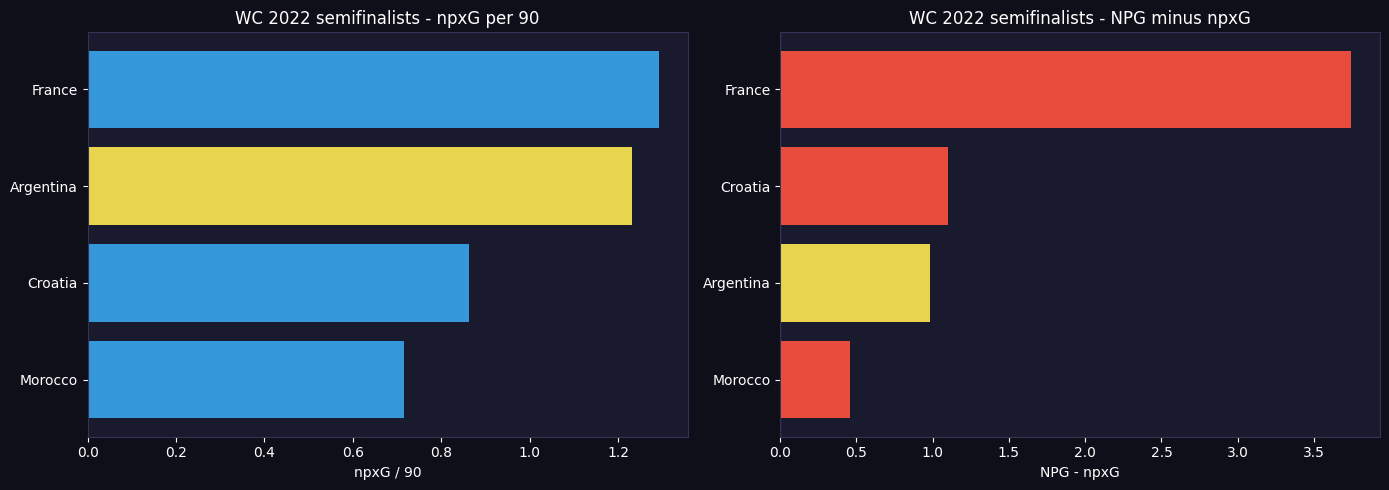

In [31]:
# Terminology correction:
# npxG = xG excluding in-game penalties.
# open-play xG would also remove set-pieces, which is NOT what we do here.

from collections import defaultdict

def _team_shot_metrics_from_shots(team_shots, matches_played, team_minutes):
    xg_total = float(team_shots["shot_statsbomb_xg"].sum())
    pen = team_shots[team_shots["shot_type"] == "Penalty"] if "shot_type" in team_shots.columns else team_shots.iloc[0:0]
    nonpen = team_shots[team_shots["shot_type"] != "Penalty"] if "shot_type" in team_shots.columns else team_shots

    # NPG from shot events excludes own goals by construction for all teams.
    goals_total = int(team_shots["is_goal"].sum())
    goals_nonpen = int(nonpen["is_goal"].sum())

    pen_xg = float(pen["shot_statsbomb_xg"].sum())
    npxg = float(nonpen["shot_statsbomb_xg"].sum())

    minutes = float(team_minutes) if team_minutes and team_minutes > 0 else np.nan
    xg_per90 = xg_total * 90.0 / minutes if minutes and np.isfinite(minutes) else np.nan
    npxg_per90 = npxg * 90.0 / minutes if minutes and np.isfinite(minutes) else np.nan

    npg_minus_npxg = goals_nonpen - npxg
    # Simple noise gauge: Poisson approximation around expected non-pen goals = npxG
    npg_z = npg_minus_npxg / np.sqrt(npxg) if npxg > 0 else np.nan

    return {
        "matches": int(matches_played),
        "minutes": minutes,
        "shots": int(len(team_shots)),
        "xG": xg_total,
        "npxG": npxg,
        "pen_xG": pen_xg,
        "goals_shots": goals_total,
        "nonpen_goals": goals_nonpen,
        "G_minus_xG": goals_total - xg_total,
        "npg_minus_npxG": npg_minus_npxg,
        "npg_zscore": npg_z,
        "xG_per_match": xg_total / matches_played if matches_played else np.nan,
        "npxG_per_match": npxg / matches_played if matches_played else np.nan,
        "xG_per90": xg_per90,
        "npxG_per90": npxg_per90,
    }

# --- Build 2022 full-team benchmark from all matches ---
wc_match_ids = matches["match_id"].tolist()
all_shots_wc = []
match_minutes = {}

for mid in wc_match_ids:
    ev = sb.events(match_id=int(mid))

    # Match duration estimate from event stream (exclude shootout period)
    ev_reg_et = ev[ev["period"] != 5].copy() if "period" in ev.columns else ev.copy()
    if "minute" in ev_reg_et.columns and len(ev_reg_et):
        match_minutes[int(mid)] = float(ev_reg_et["minute"].max())
    else:
        match_minutes[int(mid)] = 90.0

    s = ev[ev["type"] == "Shot"].copy()
    s = s[s["period"] != 5].copy()  # exclude shootout attempts
    s["match_id"] = int(mid)
    s["is_goal"] = s["shot_outcome"] == "Goal"
    all_shots_wc.append(s)

all_shots_wc = pd.concat(all_shots_wc, ignore_index=True)

# team -> matches played and team -> minutes played
team_match_counts = defaultdict(int)
team_minutes = defaultdict(float)
for _, r in matches.iterrows():
    mid = int(r["match_id"])
    mm = float(match_minutes.get(mid, 90.0))
    team_match_counts[r["home_team"]] += 1
    team_match_counts[r["away_team"]] += 1
    team_minutes[r["home_team"]] += mm
    team_minutes[r["away_team"]] += mm

benchmark_rows = []
for team, n_matches in team_match_counts.items():
    team_shots = all_shots_wc[all_shots_wc["team"] == team].copy()
    row = {"team": team}
    row.update(_team_shot_metrics_from_shots(team_shots, n_matches, team_minutes[team]))
    benchmark_rows.append(row)

benchmark_2022 = pd.DataFrame(benchmark_rows)
benchmark_2022 = benchmark_2022.sort_values("npxG_per90", ascending=False).reset_index(drop=True)

# Identify 2022 semifinalists directly from Semi-finals stage
sf_matches_2022 = matches[matches["competition_stage"] == "Semi-finals"]
semifinalists_2022 = sorted(set(sf_matches_2022["home_team"]).union(set(sf_matches_2022["away_team"])))
semi_benchmark_2022 = benchmark_2022[benchmark_2022["team"].isin(semifinalists_2022)].copy()

# Ranks among all 32 teams (per90-based)
benchmark_2022["rank_npxG_per90"] = benchmark_2022["npxG_per90"].rank(ascending=False, method="min")
benchmark_2022["rank_npg_minus_npxG"] = benchmark_2022["npg_minus_npxG"].rank(ascending=False, method="min")
arg_rank = benchmark_2022[benchmark_2022["team"] == "Argentina"][
    ["rank_npxG_per90", "rank_npg_minus_npxG", "npxG_per90", "npg_minus_npxG", "npg_zscore"]
].iloc[0]

# Tournament distribution anchors
npxg_p90_median_2022 = float(benchmark_2022["npxG_per90"].median())
npxg_p90_q25_2022 = float(benchmark_2022["npxG_per90"].quantile(0.25))
npxg_p90_q75_2022 = float(benchmark_2022["npxG_per90"].quantile(0.75))

# --- Explicit own-goal verification (not inferred only from 8-7) ---
own_goal_events = events_df[events_df["type"].isin(["Own Goal For", "Own Goal Against"])].copy()
own_goal_cols = [c for c in ["match_id", "minute", "team", "player", "type", "opponent", "competition_stage"] if c in own_goal_events.columns]
own_goal_check = own_goal_events[own_goal_cols].sort_values(["match_id", "minute"]).reset_index(drop=True)

print("2022 benchmark built for", len(benchmark_2022), "teams")
print("2022 semifinalists:", semifinalists_2022)
print("\nArgentina ranks among 2022 teams (per90-based):")
print(arg_rank)
print(f"\n2022 npxG/90 distribution: median={npxg_p90_median_2022:.3f}, IQR=[{npxg_p90_q25_2022:.3f}, {npxg_p90_q75_2022:.3f}]")
print("\nOwn-goal events in Argentina matches (explicit check):")
display(own_goal_check if len(own_goal_check) else pd.DataFrame({"info": ["No own-goal event found in loaded events."]}))

# --- Historical context: semifinalists across available FIFA World Cup seasons in StatsBomb ---
wc_comp = competitions[competitions["competition_name"] == "FIFA World Cup"].copy()
wc_comp = wc_comp.sort_values("season_name")

historical_rows = []
for _, comp_row in wc_comp.iterrows():
    cid = int(comp_row["competition_id"])
    sid = int(comp_row["season_id"])
    sname = str(comp_row["season_name"])

    mdf = sb.matches(competition_id=cid, season_id=sid)
    sf = mdf[mdf["competition_stage"] == "Semi-finals"]
    if sf.empty:
        continue
    s_teams = sorted(set(sf["home_team"]).union(set(sf["away_team"])))

    cnt = defaultdict(int)
    tmin = defaultdict(float)
    mids = mdf["match_id"].tolist()
    shots_tour = []

    # Build match-minute map for this tournament
    tour_match_minutes = {}
    for mid in mids:
        ev = sb.events(match_id=int(mid))
        ev_reg_et = ev[ev["period"] != 5].copy() if "period" in ev.columns else ev.copy()
        if "minute" in ev_reg_et.columns and len(ev_reg_et):
            tour_match_minutes[int(mid)] = float(ev_reg_et["minute"].max())
        else:
            tour_match_minutes[int(mid)] = 90.0

        s = ev[ev["type"] == "Shot"].copy()
        s = s[s["period"] != 5].copy()
        s["is_goal"] = s["shot_outcome"] == "Goal"
        shots_tour.append(s)

    shots_tour = pd.concat(shots_tour, ignore_index=True)

    for _, mr in mdf.iterrows():
        cnt[mr["home_team"]] += 1
        cnt[mr["away_team"]] += 1
        mm = float(tour_match_minutes[int(mr["match_id"])] )
        tmin[mr["home_team"]] += mm
        tmin[mr["away_team"]] += mm

    for t in s_teams:
        ts = shots_tour[shots_tour["team"] == t].copy()
        met = _team_shot_metrics_from_shots(ts, cnt[t], tmin[t])
        met.update({"season": sname, "team": t})
        historical_rows.append(met)

historical_sf = pd.DataFrame(historical_rows)
historical_sf = historical_sf.sort_values(["season", "npxG_per90"], ascending=[True, False]).reset_index(drop=True)

display_cols = ["team", "matches", "minutes", "shots", "xG", "npxG", "goals_shots", "npg_minus_npxG", "npxG_per90"]
print("\nSemi-finalists benchmark (WC 2022):")
display(semi_benchmark_2022[display_cols].sort_values("npxG_per90", ascending=False))

print("Historical semifinalists benchmark (all FIFA WC seasons available in StatsBomb open data):")
display(historical_sf[["season"] + display_cols])

# Quick benchmark chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f0f1a")

ax = axes[0]
ax.set_facecolor("#1a1a2e")
semi_plot = semi_benchmark_2022.sort_values("npxG_per90", ascending=True)
ax.barh(semi_plot["team"], semi_plot["npxG_per90"], color=["#e8d44d" if t == "Argentina" else "#3498db" for t in semi_plot["team"]])
ax.set_title("WC 2022 semifinalists - npxG per 90", color="white")
ax.set_xlabel("npxG / 90", color="white")
ax.tick_params(colors="white")
for sp in ax.spines.values():
    sp.set_color("#333355")

ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
semi_plot2 = semi_benchmark_2022.sort_values("npg_minus_npxG", ascending=True)
ax2.barh(semi_plot2["team"], semi_plot2["npg_minus_npxG"], color=["#e8d44d" if t == "Argentina" else "#e74c3c" for t in semi_plot2["team"]])
ax2.axvline(0, color="white", ls="--", lw=0.8)
ax2.set_title("WC 2022 semifinalists - NPG minus npxG", color="white")
ax2.set_xlabel("NPG - npxG", color="white")
ax2.tick_params(colors="white")
for sp in ax2.spines.values():
    sp.set_color("#333355")

fig.tight_layout()
plt.show()

In [29]:
from matplotlib.backends.backend_pdf import PdfPages

# Keep only full modern editions for fair historical comparison
# (StatsBomb has partial historical coverage for older tournaments)
full_wc_editions = []
for _, comp_row in wc_comp.iterrows():
    cid = int(comp_row["competition_id"])
    sid = int(comp_row["season_id"])
    mdf = sb.matches(competition_id=cid, season_id=sid)
    if len(mdf) >= 60:  # practical threshold for near-full tournament coverage
        full_wc_editions.append(str(comp_row["season_name"]))

historical_sf_full = historical_sf[historical_sf["season"].isin(full_wc_editions)].copy()

PDF_PATH_V5 = r"c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v5_benchmark_decision.pdf"

with PdfPages(PDF_PATH_V5) as pdf:
    # Page 1: benchmark headline
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.95, "Argentina 2022 - Benchmark Decision Note", ha="center", color="white", fontsize=17, fontweight="bold")
    fig.text(0.5, 0.92, "Focus: sustainability of finishing and comparative strength", ha="center", color="#aeb6bf", fontsize=10)

    # KPI strip from benchmark
    arg_row = benchmark_2022[benchmark_2022["team"] == "Argentina"].iloc[0]
    fra_row = benchmark_2022[benchmark_2022["team"] == "France"].iloc[0]

    kpis = [
        ("Argentina npxG/m", f"{arg_row['npxG_per_match']:.2f}"),
        ("Argentina NPG-npxG", f"{arg_row['npg_minus_npxG']:+.2f}"),
        ("Rank npxG/m (2022)", f"{int(arg_row['rank_npxG_pm'])}/32"),
        ("Rank NPG-npxG", f"{int(arg_row['rank_npg_minus_npxG'])}/32"),
        ("France npxG/m", f"{fra_row['npxG_per_match']:.2f}"),
        ("France NPG-npxG", f"{fra_row['npg_minus_npxG']:+.2f}"),
    ]
    for i, (k, v) in enumerate(kpis):
        x0 = 0.08 + (i % 3) * 0.29
        y0 = 0.77 - (i // 3) * 0.13
        fig.add_artist(plt.Rectangle((x0, y0), 0.25, 0.1, transform=fig.transFigure,
                                     facecolor="#1a1a2e", edgecolor="#3498db", lw=1.0))
        fig.text(x0 + 0.125, y0 + 0.06, v, ha="center", color="#e8d44d", fontsize=14, fontweight="bold")
        fig.text(x0 + 0.125, y0 + 0.02, k, ha="center", color="#c7d5e0", fontsize=8)

    txt = (
        "Key decision answer:\n"
        "Argentina's 2022 finishing was positive but not extreme relative to elite peers.\n"
        "They are #6/32 in npxG per match and #11/32 in NPG-npxG, while France outperforms in both creation and finishing.\n"
        "So the profile is strong and plausible, but not uniquely 'unsustainable-hot' nor clearly best-in-class on chance creation.\n\n"
        "Method note:\n"
        "- npxG = xG excluding in-game penalties (not 'open-play xG').\n"
        "- Shootout attempts excluded.\n"
        "- Own-goal event explicitly confirmed (Enzo Fernandez, vs Australia, minute 76)."
    )
    fig.text(0.08, 0.46, txt, color="#c7d5e0", fontsize=10.5, linespacing=1.6)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 2: semifinalists benchmark charts + table
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "WC 2022 Semi-finalists Benchmark", ha="center", color="white", fontsize=14, fontweight="bold")

    ax1 = fig.add_axes([0.08, 0.64, 0.84, 0.24])
    ax1.set_facecolor("#1a1a2e")
    semi_plot = semi_benchmark_2022.sort_values("npxG_per_match", ascending=True)
    ax1.barh(semi_plot["team"], semi_plot["npxG_per_match"], color=["#e8d44d" if t=="Argentina" else "#3498db" for t in semi_plot["team"]])
    ax1.set_title("npxG per match", color="white", fontsize=11)
    ax1.tick_params(colors="white")
    ax1.set_xlabel("npxG / match", color="white")
    for sp in ax1.spines.values():
        sp.set_color("#333355")

    ax2 = fig.add_axes([0.08, 0.35, 0.84, 0.24])
    ax2.set_facecolor("#1a1a2e")
    semi_plot2 = semi_benchmark_2022.sort_values("npg_minus_npxG", ascending=True)
    ax2.barh(semi_plot2["team"], semi_plot2["npg_minus_npxG"], color=["#e8d44d" if t=="Argentina" else "#e74c3c" for t in semi_plot2["team"]])
    ax2.axvline(0, color="white", lw=0.8, ls="--")
    ax2.set_title("Non-penalty goals minus npxG", color="white", fontsize=11)
    ax2.tick_params(colors="white")
    ax2.set_xlabel("NPG - npxG", color="white")
    for sp in ax2.spines.values():
        sp.set_color("#333355")

    ax_tbl = fig.add_axes([0.06, 0.05, 0.88, 0.23])
    ax_tbl.axis("off")
    tbl_cols = ["team", "npxG_per_match", "npg_minus_npxG", "xG", "npxG", "goals_shots"]
    tbl_df = semi_benchmark_2022[tbl_cols].sort_values("npxG_per_match", ascending=False).copy()
    tbl_df["npxG_per_match"] = tbl_df["npxG_per_match"].round(3)
    tbl_df["npg_minus_npxG"] = tbl_df["npg_minus_npxG"].round(3)
    tbl_df["xG"] = tbl_df["xG"].round(2)
    tbl_df["npxG"] = tbl_df["npxG"].round(2)
    table = ax_tbl.table(cellText=tbl_df.values, colLabels=tbl_df.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)
    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor("#1a1a2e" if r > 0 else "#252545")
        cell.set_edgecolor("#333355")
        cell.set_text_props(color="white")
        if r == 0:
            cell.set_text_props(color="#e8d44d", fontweight="bold")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 3: cross-edition context (full editions only)
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Cross-edition Context (Full Editions Only)", ha="center", color="white", fontsize=14, fontweight="bold")
    fig.text(0.5, 0.935, f"Included seasons: {', '.join(sorted(historical_sf_full['season'].unique()))}", ha="center", color="#aeb6bf", fontsize=9)

    ax = fig.add_axes([0.08, 0.58, 0.84, 0.30])
    ax.set_facecolor("#1a1a2e")
    hist_plot = historical_sf_full[["season", "team", "npxG_per_match"]].copy()
    hist_plot["label"] = hist_plot["season"] + " - " + hist_plot["team"]
    hist_plot = hist_plot.sort_values("npxG_per_match")
    colors = ["#e8d44d" if (r["season"] == "2022" and r["team"] == "Argentina") else "#3498db" for _, r in hist_plot.iterrows()]
    ax.barh(hist_plot["label"], hist_plot["npxG_per_match"], color=colors)
    ax.set_title("Semi-finalists npxG per match", color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_xlabel("npxG / match", color="white")
    for sp in ax.spines.values():
        sp.set_color("#333355")

    ax2 = fig.add_axes([0.08, 0.14, 0.84, 0.32])
    ax2.axis("off")
    takeaways = (
        "Decision takeaway:\n"
        "1. Argentina 2022 had top-tier chance creation, but not the highest among 2022 semi-finalists.\n"
        "2. Their non-penalty finishing overperformance is positive but moderate vs elite benchmark set.\n"
        "3. This supports a 'strong and likely reproducible base + some variance' interpretation,\n"
        "   rather than a purely unsustainable finishing spike.\n"
        "4. Next analytical step for club-level decision: connect this output layer to chance creation process\n"
        "   (xThreat, progression chains, entry passes, and defensive transition control)."
    )
    ax2.text(0, 1, takeaways, color="#c7d5e0", fontsize=11, va="top", linespacing=1.7)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF saved -> {PDF_PATH_V5}")

PDF saved -> c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v5_benchmark_decision.pdf


In [32]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec

PDF_PATH_V7 = r"c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v7_full_analysis_benchmark_fixed.pdf"

# Reuse already-computed objects from notebook
# - arg_matches, arg_shots, opp_shots, display_summary, player_stats
# - semi_benchmark_2022, benchmark_2022, historical_sf_full, own_goal_check
# - npxg_p90_median_2022, npxg_p90_q25_2022, npxg_p90_q75_2022

# Core aggregates
xg_for_total = float(arg_shots["shot_statsbomb_xg"].sum())
xg_against_total = float(opp_shots["shot_statsbomb_xg"].sum())
shots_for_total = int(len(arg_shots))
shots_against_total = int(len(opp_shots))

# npxG (non-penalty xG)
arg_pen = arg_shots[arg_shots["shot_type"] == "Penalty"] if "shot_type" in arg_shots.columns else arg_shots.iloc[0:0]
opp_pen = opp_shots[opp_shots["shot_type"] == "Penalty"] if "shot_type" in opp_shots.columns else opp_shots.iloc[0:0]
arg_npxg = float(arg_shots[arg_shots["shot_type"] != "Penalty"]["shot_statsbomb_xg"].sum()) if "shot_type" in arg_shots.columns else xg_for_total
opp_npxg = float(opp_shots[opp_shots["shot_type"] != "Penalty"]["shot_statsbomb_xg"].sum()) if "shot_type" in opp_shots.columns else xg_against_total

# Scoreboard goals (authoritative total)
goals_for_score = int(arg_matches["arg_score"].sum())
goals_against_score = int(arg_matches["opp_score"].sum())
goals_for_shot = int(arg_shots["is_goal"].sum())
goals_against_shot = int(opp_shots["is_goal"].sum())

arg_bmk = benchmark_2022[benchmark_2022["team"] == "Argentina"].iloc[0]
fra_bmk = benchmark_2022[benchmark_2022["team"] == "France"].iloc[0]

# Full 2022 distribution table for evidencing ranks
dist_2022 = benchmark_2022[["team", "npxG_per90", "npg_minus_npxG", "rank_npxG_per90", "rank_npg_minus_npxG"]].copy()
dist_2022 = dist_2022.sort_values("npxG_per90", ascending=False).reset_index(drop=True)

def _fmt_signed(v):
    return f"{v:+.2f}"

with PdfPages(PDF_PATH_V7) as pdf:

    # PAGE 1 - Cover + methodology
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.955, "Argentina WC 2022 - Full Analysis + Benchmark", ha="center", color="white", fontsize=17, fontweight="bold")
    fig.text(0.5, 0.927, "Shots, shotmaps, xG, npxG, players, semi-finalist benchmark", ha="center", color="#aeb6bf", fontsize=10)

    kpis = [
        ("Shots For", f"{shots_for_total}"),
        ("Shots Against", f"{shots_against_total}"),
        ("xG For", f"{xg_for_total:.2f}"),
        ("xG Against", f"{xg_against_total:.2f}"),
        ("npxG For", f"{arg_npxg:.2f}"),
        ("npxG Against", f"{opp_npxg:.2f}"),
        ("Scoreboard GF", f"{goals_for_score}"),
        ("Scoreboard GA", f"{goals_against_score}"),
    ]
    for i, (k, v) in enumerate(kpis):
        row = i // 4
        col = i % 4
        x0 = 0.07 + col * 0.225
        y0 = 0.78 - row * 0.115
        fig.add_artist(plt.Rectangle((x0, y0), 0.19, 0.09, transform=fig.transFigure,
                                     facecolor="#1a1a2e", edgecolor="#3498db", lw=1.0))
        fig.text(x0 + 0.095, y0 + 0.055, v, ha="center", color="#e8d44d", fontsize=13, fontweight="bold")
        fig.text(x0 + 0.095, y0 + 0.018, k, ha="center", color="#c7d5e0", fontsize=8)

    own_goal_msg = "none found"
    if len(own_goal_check):
        r0 = own_goal_check.iloc[0]
        own_goal_msg = f"match {int(r0['match_id'])}, minute {int(r0['minute'])}, {r0['type']} ({r0['player']})"

    fig.text(
        0.07, 0.56,
        "Method notes:\n"
        "- Shootout attempts excluded (period 5).\n"
        "- npxG = xG excluding in-game penalties (not open-play xG).\n"
        f"- Goals Against scoreboard = {goals_against_score}; opponent shot-goals = {goals_against_shot}.\n"
        f"- Own-goal event explicit check: {own_goal_msg}.",
        color="#c7d5e0", fontsize=10, linespacing=1.6
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 2 - Match shotmaps
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Shotmaps by Match", ha="center", color="white", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(3, 3, figure=fig, left=0.04, right=0.96, top=0.92, bottom=0.04, hspace=0.28, wspace=0.08)

    for i, mid in enumerate(arg_matches["match_id"]):
        r, c = divmod(i, 3)
        ax = fig.add_subplot(gs[r, c])
        m = arg_matches[arg_matches["match_id"] == mid].iloc[0]
        af = arg_shots[arg_shots["match_id"] == mid]
        oa = opp_shots[opp_shots["match_id"] == mid]

        p = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#1a1a2e", line_color="#c7d5e0")
        p.draw(ax=ax)
        p.scatter(af["x"], af["y"], s=af["shot_statsbomb_xg"] * 900 + 20, color="#3498db", edgecolors="white", lw=0.4, alpha=0.7, ax=ax)
        p.scatter(af[af["is_goal"]]["x"], af[af["is_goal"]]["y"], s=af[af["is_goal"]]["shot_statsbomb_xg"] * 900 + 50,
                  color="#e8d44d", edgecolors="white", lw=0.5, marker="*", alpha=0.95, ax=ax)
        p.scatter(120 - oa["x"], 80 - oa["y"], s=oa["shot_statsbomb_xg"] * 900 + 20, color="#e74c3c", edgecolors="white", lw=0.3, alpha=0.45, ax=ax)
        ax.set_title(
            f"ARG {int(m['arg_score'])}-{int(m['opp_score'])} {m['opponent']}\n"
            f"xG {af['shot_statsbomb_xg'].sum():.2f} - {oa['shot_statsbomb_xg'].sum():.2f}",
            color="white", fontsize=8
        )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 3 - xG charts + match table
    fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69), facecolor="#0f0f1a", gridspec_kw={"height_ratios": [1, 1.35]})
    ax1, ax2 = axes
    for ax in axes:
        ax.set_facecolor("#1a1a2e")

    lbl = [f"vs {x}" for x in display_summary["Opponent"]]
    xx = np.arange(len(lbl))
    w = 0.35

    ax1.bar(xx - w/2, display_summary["xGF"], w, color="#3498db", label="xGF")
    ax1.bar(xx + w/2, display_summary["xGA"], w, color="#e74c3c", label="xGA")
    ax1.set_xticks(xx)
    ax1.set_xticklabels(lbl, color="white", fontsize=8)
    ax1.tick_params(colors="white")
    ax1.set_title("xG for vs against by match", color="white")
    ax1.legend(facecolor="#1a1a2e", labelcolor="white")

    ax2.axis("off")
    table_cols = ["Stage", "Opponent", "GF", "GA", "xGF", "xGA", "xG_diff", "ShotsF", "ShotsA"]
    tbl = ax2.table(cellText=display_summary[table_cols].values, colLabels=table_cols, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.45)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor("#1a1a2e" if r > 0 else "#252545")
        cell.set_edgecolor("#333355")
        cell.set_text_props(color="white")
        if r == 0:
            cell.set_text_props(color="#e8d44d", fontweight="bold")

    fig.suptitle("Match outcomes and chance quality", color="white", fontsize=14)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 4 - players + aggregate shotmap
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Player Analysis + Aggregate Shotmap", ha="center", color="white", fontsize=14, fontweight="bold")

    axl = fig.add_axes([0.08, 0.56, 0.40, 0.34])
    axr = fig.add_axes([0.54, 0.56, 0.40, 0.34])
    for ax in [axl, axr]:
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        for sp in ax.spines.values():
            sp.set_color("#333355")

    top10 = player_stats.head(10).iloc[::-1]
    axl.barh(top10["player"], top10["xg"], color="#3498db")
    axl.set_title("Top xG (short names)", color="white", fontsize=10)
    axl.set_xlabel("xG", color="white")

    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in top10["finishing"]]
    axr.barh(top10["player"], top10["finishing"], color=colors)
    axr.axvline(0, color="white", lw=0.8, ls="--")
    axr.set_title("Finishing (Goals - xG)", color="white", fontsize=10)
    axr.set_xlabel("Goals - xG", color="white")

    axm = fig.add_axes([0.08, 0.08, 0.84, 0.36])
    p = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#1a1a2e", line_color="#c7d5e0")
    p.draw(ax=axm)
    p.scatter(arg_shots[~arg_shots["is_goal"]]["x"], arg_shots[~arg_shots["is_goal"]]["y"],
              s=arg_shots[~arg_shots["is_goal"]]["shot_statsbomb_xg"]*850+20, color="#3498db", edgecolors="white", lw=0.4, alpha=0.55, ax=axm)
    p.scatter(arg_shots[arg_shots["is_goal"]]["x"], arg_shots[arg_shots["is_goal"]]["y"],
              s=arg_shots[arg_shots["is_goal"]]["shot_statsbomb_xg"]*850+50, color="#e8d44d", edgecolors="white", lw=0.6, marker="*", alpha=0.95, ax=axm)
    axm.set_title(f"Aggregate shotmap: {shots_for_total} shots, xG {xg_for_total:.2f}, npxG {arg_npxg:.2f}", color="white", fontsize=10)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 5 - benchmark with full 32-team support + semifinalists view
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Benchmark - WC 2022 (Full field + Semi-finalists)", ha="center", color="white", fontsize=14, fontweight="bold")

    ax1 = fig.add_axes([0.08, 0.64, 0.84, 0.23])
    ax1.set_facecolor("#1a1a2e")
    semi_plot = semi_benchmark_2022.sort_values("npxG_per90", ascending=True)
    ax1.barh(semi_plot["team"], semi_plot["npxG_per90"], color=["#e8d44d" if t=="Argentina" else "#3498db" for t in semi_plot["team"]])
    ax1.set_title("Semi-finalists: npxG per 90", color="white", fontsize=10)
    ax1.tick_params(colors="white")
    ax1.set_xlabel("npxG / 90", color="white")
    for sp in ax1.spines.values():
        sp.set_color("#333355")

    ax2 = fig.add_axes([0.08, 0.38, 0.84, 0.20])
    ax2.set_facecolor("#1a1a2e")
    ax2.hist(benchmark_2022["npxG_per90"], bins=12, color="#3498db", alpha=0.75, edgecolor="white")
    ax2.axvline(float(arg_bmk["npxG_per90"]), color="#e8d44d", lw=2, label=f"Argentina {arg_bmk['npxG_per90']:.2f}")
    ax2.axvline(npxg_p90_median_2022, color="#e74c3c", lw=2, ls="--", label=f"Median {npxg_p90_median_2022:.2f}")
    ax2.set_title("All 32 teams distribution: npxG per 90", color="white", fontsize=10)
    ax2.tick_params(colors="white")
    ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
    for sp in ax2.spines.values():
        sp.set_color("#333355")

    ax_tbl = fig.add_axes([0.06, 0.05, 0.88, 0.27])
    ax_tbl.axis("off")
    top12 = dist_2022.head(12).copy()
    top12["npxG_per90"] = top12["npxG_per90"].round(3)
    top12["npg_minus_npxG"] = top12["npg_minus_npxG"].round(3)
    table = ax_tbl.table(cellText=top12.values, colLabels=top12.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.35)
    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor("#1a1a2e" if r > 0 else "#252545")
        cell.set_edgecolor("#333355")
        cell.set_text_props(color="white")
        if r == 0:
            cell.set_text_props(color="#e8d44d", fontweight="bold")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 6 - critical interpretation (with noise and selection-bias caveat)
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="#0f0f1a")
    fig.text(0.5, 0.96, "Critical Interpretation", ha="center", color="white", fontsize=14, fontweight="bold")

    mex = display_summary[display_summary["Opponent"] == "Mexico"].iloc[0]
    qf = display_summary[display_summary["Opponent"] == "Netherlands"].iloc[0]
    fin = display_summary[display_summary["Opponent"] == "France"].iloc[0]

    text = (
        f"- 32-team evidence: Argentina npxG/90 rank = {int(arg_bmk['rank_npxG_per90'])}/32 (value {arg_bmk['npxG_per90']:.2f}),\n"
        f"  tournament median = {npxg_p90_median_2022:.2f}, IQR [{npxg_p90_q25_2022:.2f}, {npxg_p90_q75_2022:.2f}].\n"
        f"- Semi-finalist-only comparison is selection-biased toward elite teams; it is shown as contextual, not as global ranking proof.\n"
        f"- Finishing signal: NPG - npxG = {_fmt_signed(arg_bmk['npg_minus_npxG'])}, z-score = {arg_bmk['npg_zscore']:.2f}.\n"
        f"  This is statistically close to average finishing noise (not clearly distinguishable from mean finishing).\n"
        f"- NPG for all teams is computed from non-penalty shot goals, so own goals are excluded consistently (not only for Argentina).\n"
        f"- Mexico remains the key outlier: xGF {mex['xGF']:.2f} with 2-0 scoreline (result overperformance vs chance quality).\n"
        f"- Quarter-final Netherlands ({qf['xGF']:.2f}-{qf['xGA']:.2f}) and Final France ({fin['xGF']:.2f}-{fin['xGA']:.2f}) are high-variance states.\n"
        f"- Synthesis: strong attacking base + variance, but no evidence of extreme or unsustainable finishing spike in 2022 sample."
    )

    fig.text(0.08, 0.88, text, color="#c7d5e0", fontsize=10.8, va="top", linespacing=1.75)
    fig.text(0.5, 0.03, "StatsBomb open data via statsbombpy - June 2026", ha="center", color="#8a8aaa", fontsize=9)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF saved -> {PDF_PATH_V7}")

PDF saved -> c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v7_full_analysis_benchmark_fixed.pdf


In [33]:
from matplotlib.backends.backend_pdf import PdfPages
from football_viz_theme import apply_theme, clean_axis, COLORS
import matplotlib.gridspec as gridspec

apply_theme()

PDF_PATH_V8 = r"c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v8_full_theme.pdf"

# Core aggregates
xg_for_total = float(arg_shots["shot_statsbomb_xg"].sum())
xg_against_total = float(opp_shots["shot_statsbomb_xg"].sum())
shots_for_total = int(len(arg_shots))
shots_against_total = int(len(opp_shots))

arg_npxg = float(arg_shots[arg_shots["shot_type"] != "Penalty"]["shot_statsbomb_xg"].sum()) if "shot_type" in arg_shots.columns else xg_for_total
opp_npxg = float(opp_shots[opp_shots["shot_type"] != "Penalty"]["shot_statsbomb_xg"].sum()) if "shot_type" in opp_shots.columns else xg_against_total

goals_for_score = int(arg_matches["arg_score"].sum())
goals_against_score = int(arg_matches["opp_score"].sum())
goals_against_shot = int(opp_shots["is_goal"].sum())

arg_bmk = benchmark_2022[benchmark_2022["team"] == "Argentina"].iloc[0]
fra_bmk = benchmark_2022[benchmark_2022["team"] == "France"].iloc[0]
dist_2022 = benchmark_2022[["team", "npxG_per90", "npg_minus_npxG", "rank_npxG_per90", "rank_npg_minus_npxG"]].sort_values("npxG_per90", ascending=False).reset_index(drop=True)

with PdfPages(PDF_PATH_V8) as pdf:

    # PAGE 1: cover + method
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.5, 0.955, "Argentina WC 2022 - Full Analysis + Benchmark", ha="center", color=COLORS["text"], fontsize=17, fontweight="bold")
    fig.text(0.5, 0.927, "Styled with football_viz_theme.py", ha="center", color=COLORS["muted"], fontsize=10)

    kpis = [
        ("Shots For", f"{shots_for_total}"),
        ("Shots Against", f"{shots_against_total}"),
        ("xG For", f"{xg_for_total:.2f}"),
        ("xG Against", f"{xg_against_total:.2f}"),
        ("npxG For", f"{arg_npxg:.2f}"),
        ("npxG Against", f"{opp_npxg:.2f}"),
        ("Scoreboard GF", f"{goals_for_score}"),
        ("Scoreboard GA", f"{goals_against_score}"),
    ]
    for i, (k, v) in enumerate(kpis):
        row = i // 4
        col = i % 4
        x0 = 0.07 + col * 0.225
        y0 = 0.78 - row * 0.115
        fig.add_artist(plt.Rectangle((x0, y0), 0.19, 0.09, transform=fig.transFigure,
                                     facecolor=COLORS["neutral"], edgecolor=COLORS["grid"], lw=1.0, alpha=0.65))
        fig.text(x0 + 0.095, y0 + 0.055, v, ha="center", color=COLORS["highlight"], fontsize=13, fontweight="bold")
        fig.text(x0 + 0.095, y0 + 0.018, k, ha="center", color=COLORS["muted"], fontsize=8)

    own_goal_msg = "none found"
    if len(own_goal_check):
        r0 = own_goal_check.iloc[0]
        own_goal_msg = f"match {int(r0['match_id'])}, minute {int(r0['minute'])}, {r0['type']} ({r0['player']})"

    fig.text(
        0.07, 0.56,
        "Method notes:\n"
        "- Shootout attempts excluded (period 5).\n"
        "- npxG = xG excluding in-game penalties (not open-play xG).\n"
        f"- Goals Against scoreboard = {goals_against_score}; opponent shot-goals = {goals_against_shot}.\n"
        f"- Own-goal event explicit check: {own_goal_msg}.",
        color=COLORS["text"], fontsize=10, linespacing=1.6
    )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 2: shotmaps
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.5, 0.96, "Shotmaps by Match", ha="center", color=COLORS["text"], fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(3, 3, figure=fig, left=0.04, right=0.96, top=0.92, bottom=0.04, hspace=0.28, wspace=0.08)

    for i, mid in enumerate(arg_matches["match_id"]):
        r, c = divmod(i, 3)
        ax = fig.add_subplot(gs[r, c])
        m = arg_matches[arg_matches["match_id"] == mid].iloc[0]
        af = arg_shots[arg_shots["match_id"] == mid]
        oa = opp_shots[opp_shots["match_id"] == mid]

        p = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color=COLORS["bg"], line_color=COLORS["grid"])
        p.draw(ax=ax)
        p.scatter(af["x"], af["y"], s=af["shot_statsbomb_xg"] * 900 + 20, color=COLORS["highlight"], edgecolors=COLORS["text"], lw=0.35, alpha=0.7, ax=ax)
        p.scatter(af[af["is_goal"]]["x"], af[af["is_goal"]]["y"], s=af[af["is_goal"]]["shot_statsbomb_xg"] * 900 + 50,
                  color=COLORS["accent"], edgecolors=COLORS["text"], lw=0.5, marker="*", alpha=0.95, ax=ax)
        p.scatter(120 - oa["x"], 80 - oa["y"], s=oa["shot_statsbomb_xg"] * 900 + 20, color=COLORS["bad"], edgecolors=COLORS["text"], lw=0.2, alpha=0.4, ax=ax)
        ax.set_title(
            f"ARG {int(m['arg_score'])}-{int(m['opp_score'])} {m['opponent']}\n"
            f"xG {af['shot_statsbomb_xg'].sum():.2f} - {oa['shot_statsbomb_xg'].sum():.2f}",
            color=COLORS["text"], fontsize=8
        )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 3: xG + table
    fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69), gridspec_kw={"height_ratios": [1, 1.35]})
    ax1, ax2 = axes
    clean_axis(ax1)

    lbl = [f"vs {x}" for x in display_summary["Opponent"]]
    xx = np.arange(len(lbl))
    w = 0.35
    ax1.bar(xx - w/2, display_summary["xGF"], w, color=COLORS["highlight"], label="xGF")
    ax1.bar(xx + w/2, display_summary["xGA"], w, color=COLORS["bad"], label="xGA")
    ax1.set_xticks(xx)
    ax1.set_xticklabels(lbl, color=COLORS["muted"], fontsize=8)
    ax1.set_title("xG for vs against by match", color=COLORS["text"])
    leg = ax1.legend(facecolor=COLORS["bg"], edgecolor=COLORS["grid"], fontsize=8)
    for t in leg.get_texts():
        t.set_color(COLORS["text"])

    ax2.axis("off")
    table_cols = ["Stage", "Opponent", "GF", "GA", "xGF", "xGA", "xG_diff", "ShotsF", "ShotsA"]
    tbl = ax2.table(cellText=display_summary[table_cols].values, colLabels=table_cols, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.45)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor(COLORS["neutral"] if r > 0 else COLORS["bg"])
        cell.set_edgecolor(COLORS["grid"])
        cell.set_text_props(color=COLORS["text"])
        if r == 0:
            cell.set_text_props(color=COLORS["highlight"], fontweight="bold")

    fig.suptitle("Match outcomes and chance quality", color=COLORS["text"], fontsize=14)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 4: players + aggregate map
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.5, 0.96, "Player Analysis + Aggregate Shotmap", ha="center", color=COLORS["text"], fontsize=14, fontweight="bold")

    axl = fig.add_axes([0.08, 0.56, 0.40, 0.34])
    axr = fig.add_axes([0.54, 0.56, 0.40, 0.34])
    clean_axis(axl)
    clean_axis(axr)

    top10 = player_stats.head(10).iloc[::-1]
    axl.barh(top10["player"], top10["xg"], color=COLORS["highlight"])
    axl.set_title("Top xG (short names)", color=COLORS["text"], fontsize=10)
    axl.set_xlabel("xG", color=COLORS["muted"])

    colors = [COLORS["good"] if v >= 0 else COLORS["bad"] for v in top10["finishing"]]
    axr.barh(top10["player"], top10["finishing"], color=colors)
    axr.axvline(0, color=COLORS["text"], lw=0.8, ls="--")
    axr.set_title("Finishing (Goals - xG)", color=COLORS["text"], fontsize=10)
    axr.set_xlabel("Goals - xG", color=COLORS["muted"])

    axm = fig.add_axes([0.08, 0.08, 0.84, 0.36])
    p = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color=COLORS["bg"], line_color=COLORS["grid"])
    p.draw(ax=axm)
    p.scatter(arg_shots[~arg_shots["is_goal"]]["x"], arg_shots[~arg_shots["is_goal"]]["y"],
              s=arg_shots[~arg_shots["is_goal"]]["shot_statsbomb_xg"]*850+20, color=COLORS["highlight"], edgecolors=COLORS["text"], lw=0.3, alpha=0.55, ax=axm)
    p.scatter(arg_shots[arg_shots["is_goal"]]["x"], arg_shots[arg_shots["is_goal"]]["y"],
              s=arg_shots[arg_shots["is_goal"]]["shot_statsbomb_xg"]*850+50, color=COLORS["accent"], edgecolors=COLORS["text"], lw=0.5, marker="*", alpha=0.95, ax=axm)
    axm.set_title(f"Aggregate shotmap: {shots_for_total} shots, xG {xg_for_total:.2f}, npxG {arg_npxg:.2f}", color=COLORS["text"], fontsize=10)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 5: benchmark
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.5, 0.96, "Benchmark - WC 2022 (Full field + Semi-finalists)", ha="center", color=COLORS["text"], fontsize=14, fontweight="bold")

    ax1 = fig.add_axes([0.08, 0.64, 0.84, 0.23])
    clean_axis(ax1)
    semi_plot = semi_benchmark_2022.sort_values("npxG_per90", ascending=True)
    ax1.barh(semi_plot["team"], semi_plot["npxG_per90"], color=[COLORS["accent"] if t=="Argentina" else COLORS["neutral"] for t in semi_plot["team"]])
    ax1.set_title("Semi-finalists: npxG per 90", color=COLORS["text"], fontsize=10)
    ax1.set_xlabel("npxG / 90", color=COLORS["muted"])

    ax2 = fig.add_axes([0.08, 0.38, 0.84, 0.20])
    clean_axis(ax2)
    ax2.hist(benchmark_2022["npxG_per90"], bins=12, color=COLORS["highlight"], alpha=0.8, edgecolor=COLORS["grid"])
    ax2.axvline(float(arg_bmk["npxG_per90"]), color=COLORS["accent"], lw=2, label=f"Argentina {arg_bmk['npxG_per90']:.2f}")
    ax2.axvline(npxg_p90_median_2022, color=COLORS["muted"], lw=1.5, ls="--", label=f"Median {npxg_p90_median_2022:.2f}")
    ax2.set_title("All 32 teams distribution: npxG per 90", color=COLORS["text"], fontsize=10)
    leg = ax2.legend(facecolor=COLORS["bg"], edgecolor=COLORS["grid"], fontsize=8)
    for t in leg.get_texts():
        t.set_color(COLORS["text"])

    ax_tbl = fig.add_axes([0.06, 0.05, 0.88, 0.27])
    ax_tbl.axis("off")
    top12 = dist_2022.head(12).copy()
    top12["npxG_per90"] = top12["npxG_per90"].round(3)
    top12["npg_minus_npxG"] = top12["npg_minus_npxG"].round(3)
    table = ax_tbl.table(cellText=top12.values, colLabels=top12.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.35)
    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor(COLORS["neutral"] if r > 0 else COLORS["bg"])
        cell.set_edgecolor(COLORS["grid"])
        cell.set_text_props(color=COLORS["text"])
        if r == 0:
            cell.set_text_props(color=COLORS["highlight"], fontweight="bold")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PAGE 6: interpretation
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.5, 0.96, "Critical Interpretation", ha="center", color=COLORS["text"], fontsize=14, fontweight="bold")

    mex = display_summary[display_summary["Opponent"] == "Mexico"].iloc[0]
    qf = display_summary[display_summary["Opponent"] == "Netherlands"].iloc[0]
    fin = display_summary[display_summary["Opponent"] == "France"].iloc[0]

    text = (
        f"- 32-team evidence: Argentina npxG/90 rank = {int(arg_bmk['rank_npxG_per90'])}/32 (value {arg_bmk['npxG_per90']:.2f}),\n"
        f"  tournament median = {npxg_p90_median_2022:.2f}, IQR [{npxg_p90_q25_2022:.2f}, {npxg_p90_q75_2022:.2f}].\n"
        f"- Semi-finalist-only comparison is selection-biased toward elite teams; it is contextual, not global proof.\n"
        f"- Finishing signal: NPG - npxG = {arg_bmk['npg_minus_npxG']:+.2f}, z-score = {arg_bmk['npg_zscore']:.2f}.\n"
        f"  This is close to average finishing noise, not clearly different from mean finishing.\n"
        f"- NPG for all teams is computed from non-penalty shot goals, so own goals are excluded consistently.\n"
        f"- Mexico outlier: xGF {mex['xGF']:.2f} with 2-0 scoreline.\n"
        f"- Quarter-final Netherlands ({qf['xGF']:.2f}-{qf['xGA']:.2f}) and Final France ({fin['xGF']:.2f}-{fin['xGA']:.2f}) are high-variance states.\n"
        f"- Synthesis: strong attacking base + variance, without evidence of an extreme unsustainable finishing spike."
    )

    fig.text(0.08, 0.88, text, color=COLORS["text"], fontsize=10.8, va="top", linespacing=1.75)
    fig.text(0.5, 0.03, "StatsBomb open data via statsbombpy - June 2026", ha="center", color=COLORS["muted"], fontsize=9)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF saved -> {PDF_PATH_V8}")

PDF saved -> c:\Users\BERNARF\OneDrive - National Bank of Belgium\Documents\Stats\Argentina_WC2022_Report_v8_full_theme.pdf
